In [1]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd

# Ruta del archivo ROOT
file_path = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root"

# Abrir el archivo
root_file = uproot.open(file_path)

# Mostrar los árboles que contiene
print("Árboles y claves en el ROOT file:")
for key in root_file.keys():
    print(key)


Árboles y claves en el ROOT file:
peak;12
spectrum;6
temp;3


In [2]:
#RECORRER EL ROOT PARA DATOS FINALES. EL LUNES. 

In [4]:
import uproot

file_path = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root"
root_file = uproot.open(file_path)

# Árboles principales
trees = ["peak", "spectrum", "temp"]

for tree_name in trees:
    tree = root_file[tree_name]
    print(f"Ramas en el árbol '{tree_name}':")
    print(tree.keys())
    print("-"*40)


Ramas en el árbol 'peak':
['t', 'wav', 'sweep', 'ch', 'pos']
----------------------------------------
Ramas en el árbol 'spectrum':
['t', 'wav']
----------------------------------------
Ramas en el árbol 'temp':
['t', 'temp']
----------------------------------------


In [5]:
import uproot
import numpy as np

# Archivo ROOT de entrada
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root"

# Abrir el archivo ROOT con uproot
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    spectrum_tree = file["spectrum"]
    temp_tree = file["temp"]
    
    # Cargar ramas como numpy arrays
    peak_data = peak_tree.arrays(library="np")
    spectrum_data = spectrum_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Imprimir shapes de todas las variables ---
print("=== peak ===")
for key, value in peak_data.items():
    print(f"{key}: {np.array(value).shape}")

print("\n=== spectrum ===")
for key, value in spectrum_data.items():
    print(f"{key}: {np.array(value).shape}")

print("\n=== temp ===")
for key, value in temp_data.items():
    print(f"{key}: {np.array(value).shape}")



=== peak ===
t: (2099000, 2)
wav: (2099000, 2, 5)
sweep: (2099000, 2, 5)
ch: (2099000, 5)
pos: (2099000, 5)

=== spectrum ===
t: (868, 2)
wav: (868, 2, 3, 39200)

=== temp ===
t: (12490,)
temp: (12490, 5)


/tmp/ipykernel_799/359426128.py:25: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
/tmp/ipykernel_799/359426128.py:26: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])


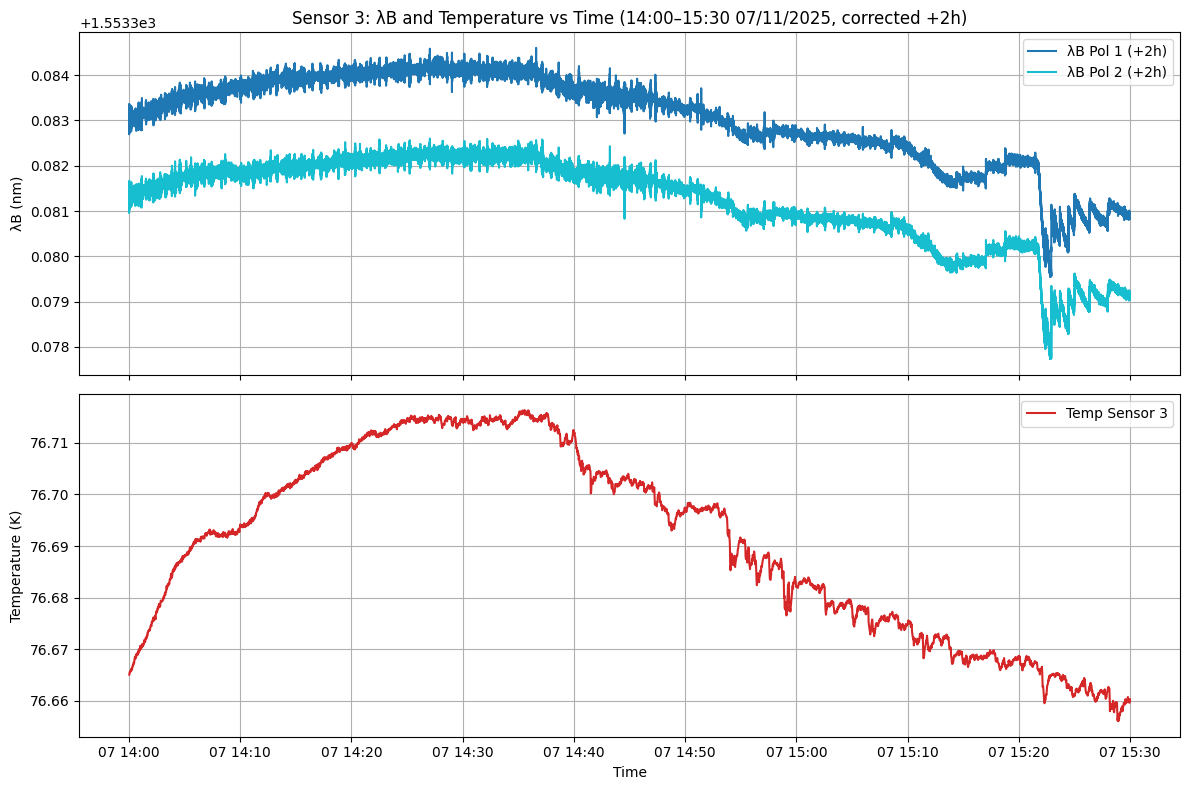

In [6]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# --- Abrir archivo ROOT ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 3 ---
peak_times = peak_data["t"][:, 0]           # primera polarización
sensor3_pol1 = peak_data["wav"][:, 0, 2]
sensor3_pol2 = peak_data["wav"][:, 1, 2]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 2]

# --- Convertir tiempos a datetime ---
peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])

# --- 💡 Corregir desfase: sumar 2 horas a los tiempos de peak ---
time_shift = datetime.timedelta(hours=2)
peak_timestamps = peak_timestamps + time_shift

# --- Definir filtro temporal ---
start_time = datetime.datetime(2025, 11, 7, 14, 0, 0)
end_time   = datetime.datetime(2025, 11, 7, 15, 30, 0)

# --- Aplicar máscaras ---
mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
peak_t_filtered = peak_timestamps[mask_peak]
sensor3_pol1_filtered = sensor3_pol1[mask_peak]
sensor3_pol2_filtered = sensor3_pol2[mask_peak]

mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)
temp_t_filtered = temp_timestamps[mask_temp]
sensor3_temp_filtered = sensor3_temp[mask_temp]

# --- Graficar en dos subplots ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# λB
ax1.plot(peak_t_filtered, sensor3_pol1_filtered*1e9, label="λB Pol 1 (+2h)", color="tab:blue")
ax1.plot(peak_t_filtered, sensor3_pol2_filtered*1e9, label="λB Pol 2 (+2h)", color="tab:cyan")
ax1.set_ylabel("λB (nm)")
ax1.set_title("Sensor 3: λB and Temperature vs Time (14:00–15:30 07/11/2025, corrected +2h)")
ax1.legend()
ax1.grid(True)

# Temperatura
ax2.plot(temp_t_filtered, sensor3_temp_filtered, label="Temp Sensor 3", color="tab:red")
ax2.set_xlabel("Time")
ax2.set_ylabel("Temperature (K)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


/tmp/ipykernel_799/3974080958.py:25: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
/tmp/ipykernel_799/3974080958.py:26: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])


---- INTERVALO DE DATOS ----
Peak data: 2025-11-07 10:24:03.237098  →  2025-11-07 15:04:45.582644
Temp data: 2025-11-07 12:22:21  →  2025-11-07 17:03:16
-----------------------------


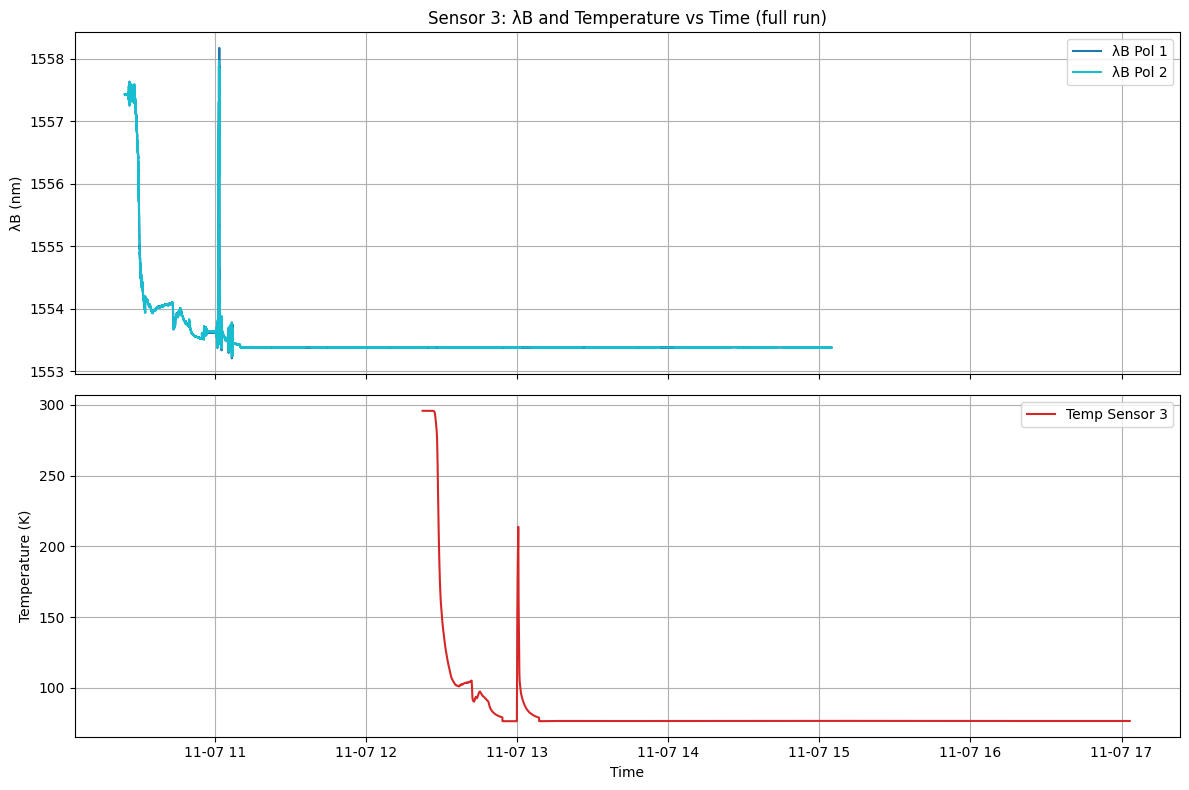

In [7]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# --- Abrir archivo ROOT ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 3 ---
peak_times = peak_data["t"][:, 0]           # primera polarización
sensor3_pol1 = peak_data["wav"][:, 0, 2]
sensor3_pol2 = peak_data["wav"][:, 1, 2]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 2]

# --- Convertir tiempos a datetime ---
peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])

# --- Mostrar inicio y fin del run ---
start_peak = np.min(peak_timestamps)
end_peak   = np.max(peak_timestamps)
start_temp = np.min(temp_timestamps)
end_temp   = np.max(temp_timestamps)

print("---- INTERVALO DE DATOS ----")
print(f"Peak data: {start_peak}  →  {end_peak}")
print(f"Temp data: {start_temp}  →  {end_temp}")
print("-----------------------------")

# --- Graficar en dos subplots (todo el rango) ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# λB (Bragg)
ax1.plot(peak_timestamps, sensor3_pol1*1e9, label="λB Pol 1", color="tab:blue")
ax1.plot(peak_timestamps, sensor3_pol2*1e9, label="λB Pol 2", color="tab:cyan")
ax1.set_ylabel("λB (nm)")
ax1.set_title("Sensor 3: λB and Temperature vs Time (full run)")
ax1.legend()
ax1.grid(True)

# Temperatura
ax2.plot(temp_timestamps, sensor3_temp, label="Temp Sensor 3", color="tab:red")
ax2.set_xlabel("Time")
ax2.set_ylabel("Temperature (K)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


/tmp/ipykernel_799/1440124646.py:25: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
/tmp/ipykernel_799/1440124646.py:26: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])


---- NUEVO INTERVALO DE DATOS ----
Peak data (shifted): 2025-11-07 12:24:03.237098  →  2025-11-07 17:04:45.582644
Temp data:            2025-11-07 12:22:21  →  2025-11-07 17:03:16
-----------------------------------


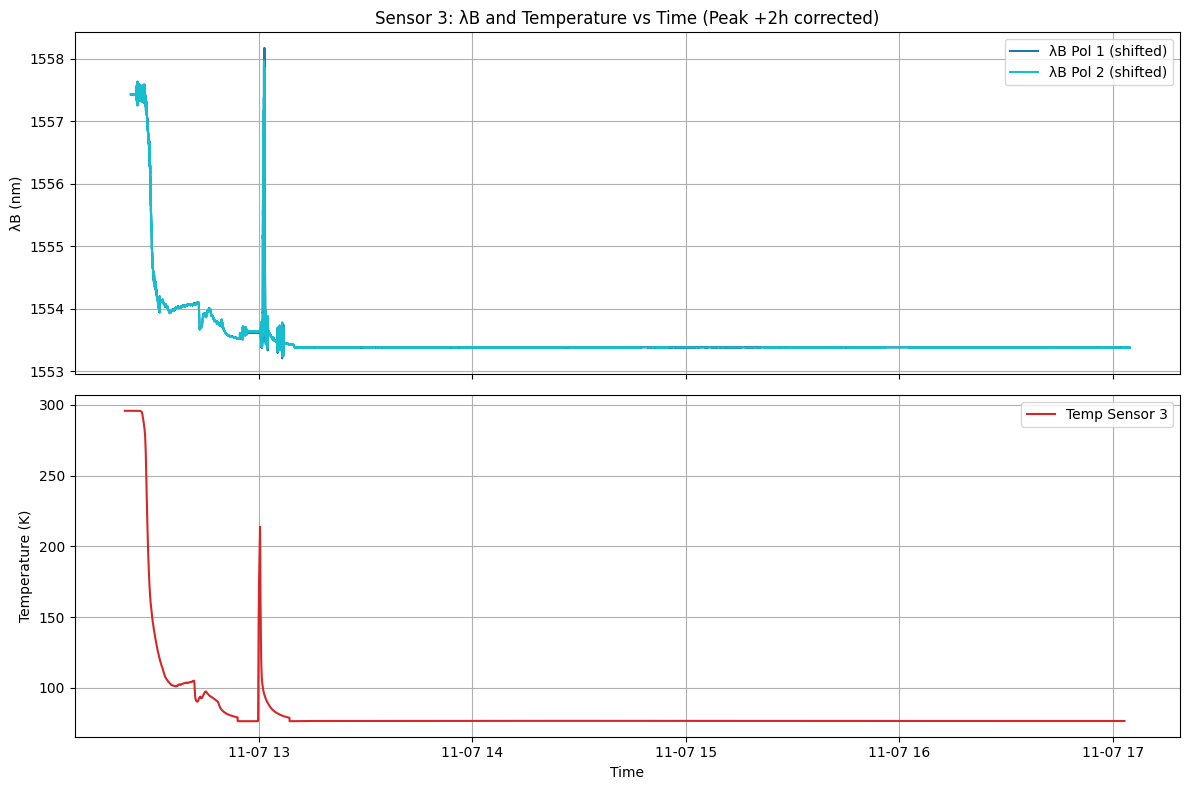

In [8]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# --- Abrir archivo ROOT ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 3 ---
peak_times = peak_data["t"][:, 0]           # primera polarización
sensor3_pol1 = peak_data["wav"][:, 0, 2]
sensor3_pol2 = peak_data["wav"][:, 1, 2]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 2]

# --- Convertir tiempos a datetime ---
peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])

# --- Corregir el desfase: sumar 2 horas a los tiempos de peak ---
time_shift = datetime.timedelta(hours=2)
peak_timestamps_shifted = peak_timestamps + time_shift

# --- Mostrar nuevo intervalo ---
print("---- NUEVO INTERVALO DE DATOS ----")
print(f"Peak data (shifted): {peak_timestamps_shifted.min()}  →  {peak_timestamps_shifted.max()}")
print(f"Temp data:            {temp_timestamps.min()}  →  {temp_timestamps.max()}")
print("-----------------------------------")

# --- Graficar ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# λB (Bragg)
ax1.plot(peak_timestamps_shifted, sensor3_pol1*1e9, label="λB Pol 1 (shifted)", color="tab:blue")
ax1.plot(peak_timestamps_shifted, sensor3_pol2*1e9, label="λB Pol 2 (shifted)", color="tab:cyan")
ax1.set_ylabel("λB (nm)")
ax1.set_title("Sensor 3: λB and Temperature vs Time (Peak +2h corrected)")
ax1.legend()
ax1.grid(True)

# Temperatura
ax2.plot(temp_timestamps, sensor3_temp, label="Temp Sensor 3", color="tab:red")
ax2.set_xlabel("Time")
ax2.set_ylabel("Temperature (K)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


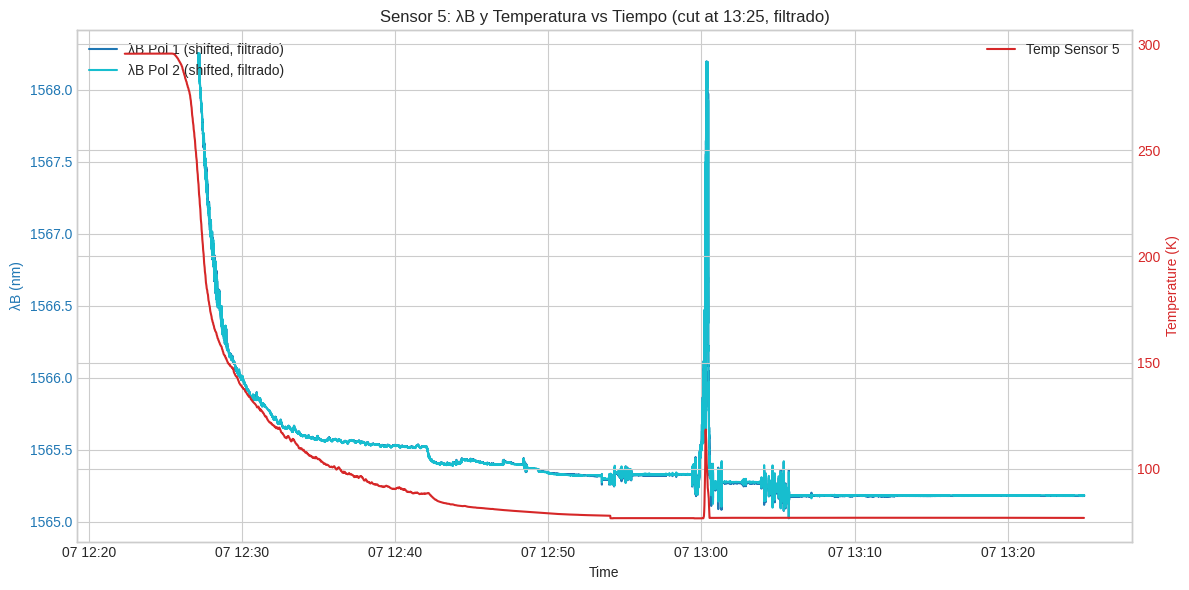

In [9]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# --- Abrir archivo ROOT ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 3 ---
peak_times = peak_data["t"][:, 0]           # primera polarización
sensor3_pol1 = peak_data["wav"][:, 0, 4]
sensor3_pol2 = peak_data["wav"][:, 1, 4]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 4]

# --- Convertir tiempos a datetime ---
peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])

# --- Corregir el desfase: sumar 2 horas a los tiempos de peak ---
time_shift = datetime.timedelta(hours=2) - datetime.timedelta(minutes=1.2)
peak_timestamps_shifted = peak_timestamps + time_shift

# --- Definir corte hasta las 13:25 ---
cut_time = datetime.datetime.combine(peak_timestamps_shifted[0].date(), datetime.time(hour=13, minute=25))

# --- Aplicar máscara de corte ---
mask_peak = peak_timestamps_shifted <= cut_time
mask_temp = temp_timestamps <= cut_time

peak_timestamps_cut = peak_timestamps_shifted[mask_peak]
sensor3_pol1_cut = sensor3_pol1[mask_peak]
sensor3_pol2_cut = sensor3_pol2[mask_peak]

temp_timestamps_cut = temp_timestamps[mask_temp]
sensor3_temp_cut = sensor3_temp[mask_temp]

# --- FILTRO: descartar valores 0 o negativos en λB ---
valid_mask_pol1 = sensor3_pol1_cut > 0
valid_mask_pol2 = sensor3_pol2_cut > 0

peak_timestamps_cut_pol1 = peak_timestamps_cut[valid_mask_pol1]
sensor3_pol1_cut_valid = sensor3_pol1_cut[valid_mask_pol1]

peak_timestamps_cut_pol2 = peak_timestamps_cut[valid_mask_pol2]
sensor3_pol2_cut_valid = sensor3_pol2_cut[valid_mask_pol2]

# --- Graficar superpuestos con dos ejes ---
fig, ax1 = plt.subplots(figsize=(12,6))

color1 = "tab:blue"
color2 = "tab:cyan"
color_temp = "tab:red"

# λB (Bragg) en eje izquierdo
ax1.plot(peak_timestamps_cut_pol1, sensor3_pol1_cut_valid*1e9, label="λB Pol 1 (shifted, filtrado)", color=color1)
ax1.plot(peak_timestamps_cut_pol2, sensor3_pol2_cut_valid*1e9, label="λB Pol 2 (shifted, filtrado)", color=color2)
ax1.set_ylabel("λB (nm)", color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.legend(loc="upper left")
ax1.grid(True)

# Temperatura en eje derecho
ax2 = ax1.twinx()
ax2.plot(temp_timestamps_cut, sensor3_temp_cut, label="Temp Sensor 5", color=color_temp)
ax2.set_ylabel("Temperature (K)", color=color_temp)
ax2.tick_params(axis='y', labelcolor=color_temp)
ax2.legend(loc="upper right")

ax1.set_xlabel("Time")
ax1.set_title("Sensor 5: λB y Temperatura vs Tiempo (cut at 13:25, filtrado)")

plt.tight_layout()
plt.show()

/tmp/ipykernel_799/892435687.py:25: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
/tmp/ipykernel_799/892435687.py:26: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])


---- DATA TIME INTERVALS ----
Peak data (+2h): 2025-11-07 12:24:03.237098  →  2025-11-07 17:04:45.582644
Temp data:       2025-11-07 12:22:21  →  2025-11-07 17:03:16
--------------------------------


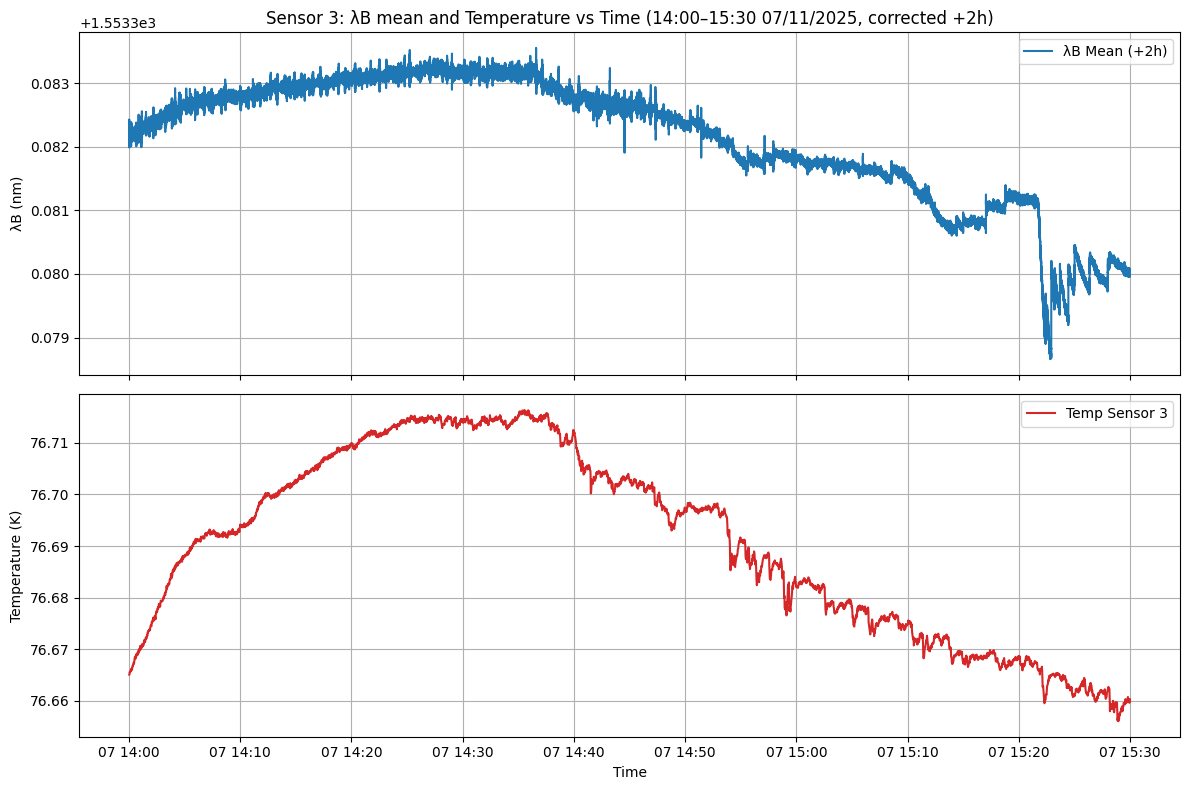

In [10]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 3 ---
peak_times = peak_data["t"][:, 0]           # first polarization
sensor3_pol1 = peak_data["wav"][:, 0, 2]
sensor3_pol2 = peak_data["wav"][:, 1, 2]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 2]

# --- Convert timestamps to datetime ---
peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])

# --- Apply +2h correction to peak timestamps ---
time_shift = datetime.timedelta(hours=2)
peak_timestamps = peak_timestamps + time_shift

# --- Print data intervals ---
print("---- DATA TIME INTERVALS ----")
print(f"Peak data (+2h): {peak_timestamps.min()}  →  {peak_timestamps.max()}")
print(f"Temp data:       {temp_timestamps.min()}  →  {temp_timestamps.max()}")
print("--------------------------------")

# --- Define time window for plotting ---
start_time = datetime.datetime(2025, 11, 7, 14, 0, 0)
end_time   = datetime.datetime(2025, 11, 7, 15, 30, 0)

# --- Apply masks ---
mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
peak_t_filtered = peak_timestamps[mask_peak]
sensor3_pol1_filtered = sensor3_pol1[mask_peak]
sensor3_pol2_filtered = sensor3_pol2[mask_peak]

mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)
temp_t_filtered = temp_timestamps[mask_temp]
sensor3_temp_filtered = sensor3_temp[mask_temp]

# --- Compute mean polarization ---
sensor3_mean = (sensor3_pol1_filtered + sensor3_pol2_filtered) / 2

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# λB mean
ax1.plot(peak_t_filtered, sensor3_mean*1e9, label="λB Mean (+2h)", color="tab:blue")
ax1.set_ylabel("λB (nm)")
ax1.set_title("Sensor 3: λB mean and Temperature vs Time (14:00–15:30 07/11/2025, corrected +2h)")
ax1.legend()
ax1.grid(True)

# Temperature
ax2.plot(temp_t_filtered, sensor3_temp_filtered, label="Temp Sensor 3", color="tab:red")
ax2.set_xlabel("Time")
ax2.set_ylabel("Temperature (K)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


/tmp/ipykernel_799/3557404399.py:25: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
/tmp/ipykernel_799/3557404399.py:26: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])


---- DATA TIME INTERVALS ----
Peak data (+2h): 2025-11-07 12:24:03.237098  →  2025-11-07 17:04:45.582644
Temp data:       2025-11-07 12:22:21  →  2025-11-07 17:03:16
--------------------------------


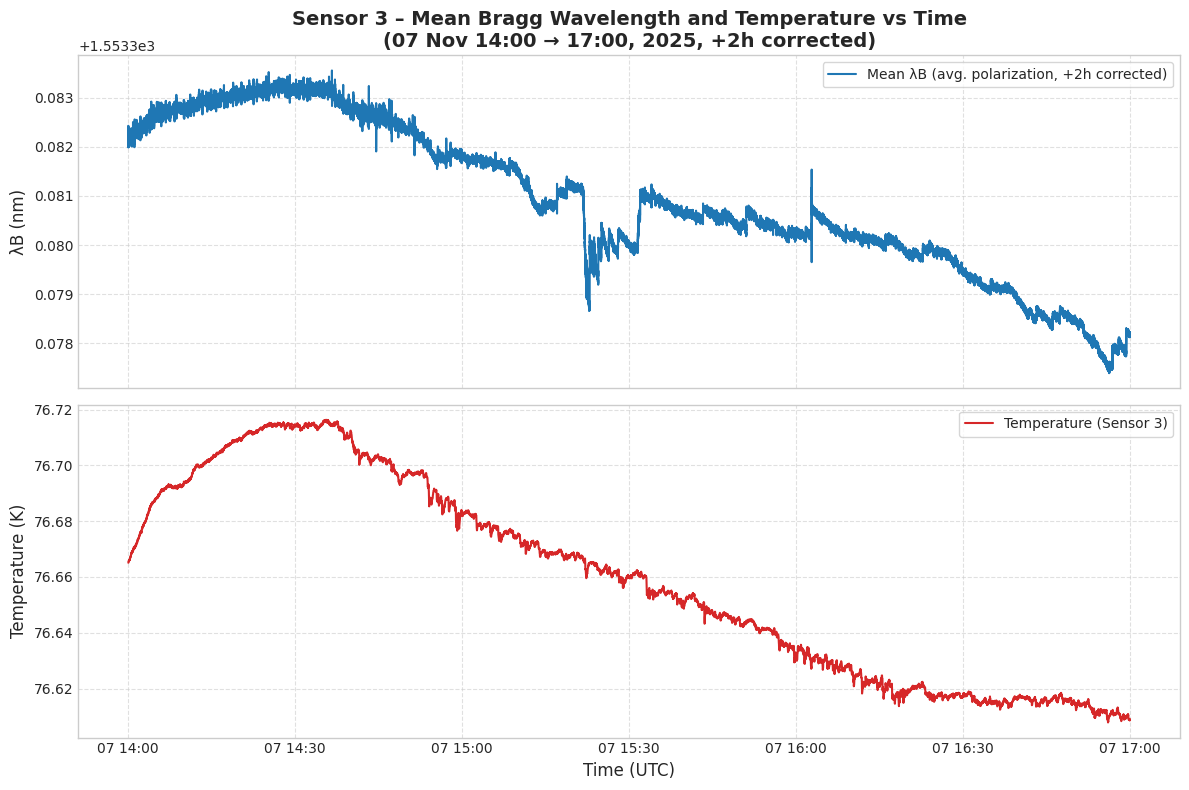

In [11]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 3 data ---
peak_times = peak_data["t"][:, 0]           # first polarization
sensor3_pol1 = peak_data["wav"][:, 0, 2]
sensor3_pol2 = peak_data["wav"][:, 1, 2]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 2]

# --- Convert timestamps to datetime ---
peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])

# --- ✅ Apply +2 hour correction to peak timestamps ---
time_shift = datetime.timedelta(hours=2)
peak_timestamps = peak_timestamps + time_shift

# --- Print intervals for confirmation ---
print("---- DATA TIME INTERVALS ----")
print(f"Peak data (+2h): {peak_timestamps.min()}  →  {peak_timestamps.max()}")
print(f"Temp data:       {temp_timestamps.min()}  →  {temp_timestamps.max()}")
print("--------------------------------")

# --- Define time window ---
start_time = datetime.datetime(2025, 11, 7, 14, 0, 0)
end_time   = datetime.datetime(2025, 11, 7, 17, 0, 0)

# --- Apply time masks ---
mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)

peak_t_filtered = peak_timestamps[mask_peak]
sensor3_pol1_filtered = sensor3_pol1[mask_peak]
sensor3_pol2_filtered = sensor3_pol2[mask_peak]

temp_t_filtered = temp_timestamps[mask_temp]
sensor3_temp_filtered = sensor3_temp[mask_temp]

# --- Compute average Bragg wavelength (λB) between polarizations ---
sensor3_mean = (sensor3_pol1_filtered + sensor3_pol2_filtered) / 2

# --- Plot: λB and Temperature vs Time ---
plt.style.use("seaborn-v0_8-whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- λB average ---
ax1.plot(peak_t_filtered, sensor3_mean * 1e9, label="Mean λB (avg. polarization, +2h corrected)",
         color="tab:blue", linewidth=1.5)
ax1.set_ylabel("λB (nm)", fontsize=12)
ax1.set_title("Sensor 3 – Mean Bragg Wavelength and Temperature vs Time\n(07 Nov 14:00 → 17:00, 2025, +2h corrected)",
              fontsize=14, weight='bold')
ax1.legend(frameon=True)
ax1.grid(True, linestyle="--", alpha=0.6)

# --- Temperature ---
ax2.plot(temp_t_filtered, sensor3_temp_filtered, label="Temperature (Sensor 3)", color="tab:red", linewidth=1.5)
ax2.set_xlabel("Time (UTC)", fontsize=12)
ax2.set_ylabel("Temperature (K)", fontsize=12)
ax2.legend(frameon=True)
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


/tmp/ipykernel_799/1847149835.py:25: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
/tmp/ipykernel_799/1847149835.py:26: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])


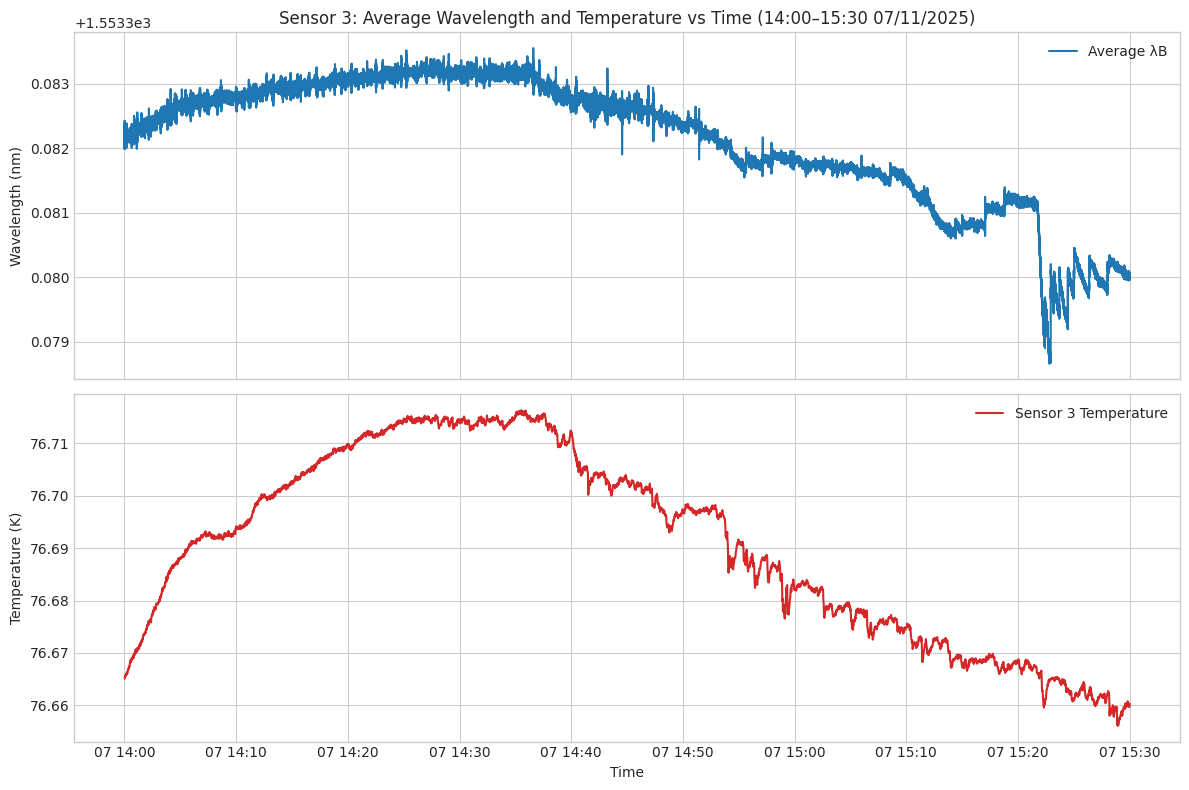

In [12]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 3 ---
peak_times = peak_data["t"][:, 0]           # first polarization timestamps
sensor3_pol1 = peak_data["wav"][:, 0, 2]    # polarization 1
sensor3_pol2 = peak_data["wav"][:, 1, 2]    # polarization 2

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 2]

# --- Convert timestamps to datetime objects ---
peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])

# --- ✅ Apply +2 hour correction to peak timestamps ---
time_shift = datetime.timedelta(hours=2)
peak_timestamps = peak_timestamps + time_shift

# --- Define time filter ---
start_time = datetime.datetime(2025, 11, 7, 14, 0, 0)
end_time   = datetime.datetime(2025, 11, 7, 15, 30, 0)

# Apply mask to peak data
mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
peak_t_filtered = peak_timestamps[mask_peak]
sensor3_pol1_filtered = sensor3_pol1[mask_peak]
sensor3_pol2_filtered = sensor3_pol2[mask_peak]

# Apply mask to temperature data
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)
temp_t_filtered = temp_timestamps[mask_temp]
sensor3_temp_filtered = sensor3_temp[mask_temp]

# --- Compute average polarization ---
sensor3_mean = (sensor3_pol1_filtered + sensor3_pol2_filtered) / 2

# --- Plot in two subplots ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# Top subplot: wavelength (λB)
ax1.plot(peak_t_filtered, sensor3_mean*1e9, label="Average λB", color="tab:blue")
ax1.set_ylabel("Wavelength (nm)")
ax1.set_title("Sensor 3: Average Wavelength and Temperature vs Time (14:00–15:30 07/11/2025)")
ax1.legend()
ax1.grid(True)

# Bottom subplot: temperature
ax2.plot(temp_t_filtered, sensor3_temp_filtered, label="Sensor 3 Temperature", color="tab:red")
ax2.set_xlabel("Time")
ax2.set_ylabel("Temperature (K)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


/tmp/ipykernel_799/1494598168.py:26: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
/tmp/ipykernel_799/1494598168.py:27: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])
/tmp/ipykernel_799/1494598168.py:68: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  peak_resampled_mean = df_peak.resample("5T").mean()
/tmp/ipykernel_799/1494598168.py:69: FutureWarning: 'T' is deprecated and will be remov

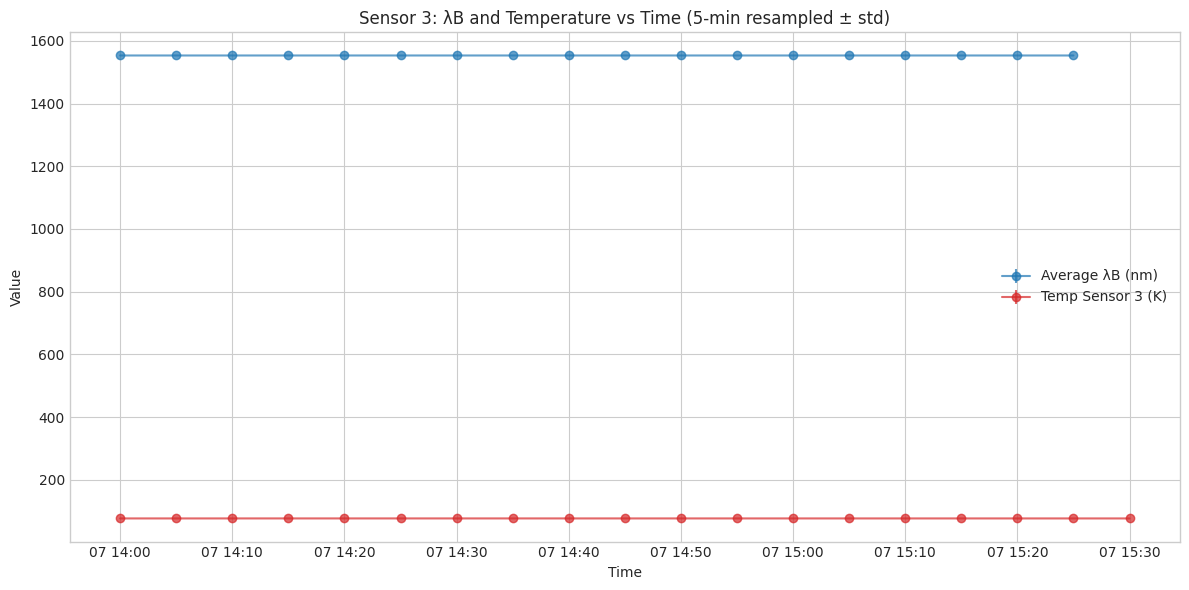

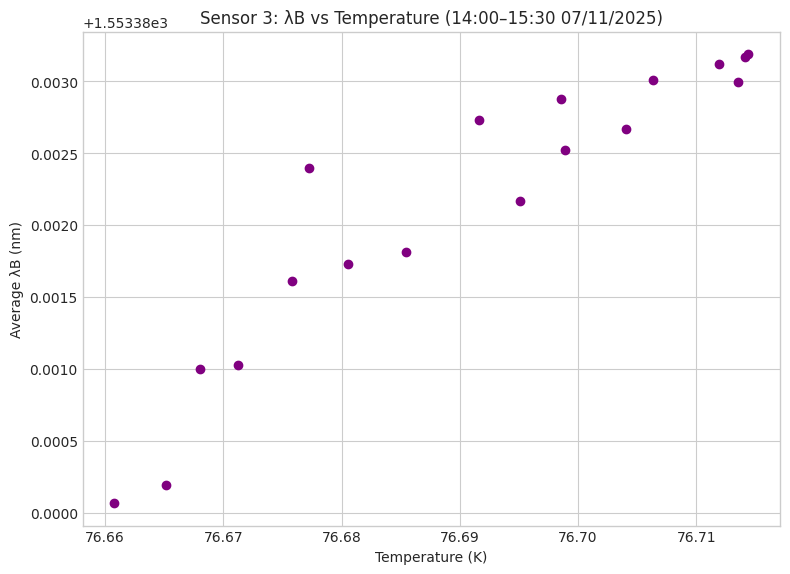

In [13]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 3 ---
peak_times = peak_data["t"][:, 0]
sensor3_pol1 = peak_data["wav"][:, 0, 2]
sensor3_pol2 = peak_data["wav"][:, 1, 2]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 2]

# --- Convert timestamps to datetime ---
peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])

# --- ✅ Apply +2 hour correction to peak timestamps ---
time_shift = datetime.timedelta(hours=2)
peak_timestamps = peak_timestamps + time_shift

# --- Define time filter ---
start_time = datetime.datetime(2025, 11, 7, 14, 0, 0)
end_time   = datetime.datetime(2025, 11, 7, 15, 30, 0)

# --- Apply mask ---
mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)

# Filtered data
peak_times_f = peak_timestamps[mask_peak]
sensor3_pol1_f = sensor3_pol1[mask_peak]
sensor3_pol2_f = sensor3_pol2[mask_peak]

temp_times_f = temp_timestamps[mask_temp]
sensor3_temp_f = sensor3_temp[mask_temp]

# --- Compute average polarization ---
sensor3_mean = (sensor3_pol1_f + sensor3_pol2_f) / 2

# --- Convert to DataFrames for resampling ---
df_peak = pd.DataFrame({
    "time": peak_times_f,
    "lambdaB_nm": sensor3_mean * 1e9,
    "lambdaB_pol1_nm": sensor3_pol1_f * 1e9,
    "lambdaB_pol2_nm": sensor3_pol2_f * 1e9
})
df_peak.set_index("time", inplace=True)

df_temp = pd.DataFrame({
    "time": temp_times_f,
    "temp_K": sensor3_temp_f
})
df_temp.set_index("time", inplace=True)

# --- Resample every 5 minutes, computing mean and std ---
peak_resampled_mean = df_peak.resample("5T").mean()
peak_resampled_std  = df_peak.resample("5T").std()

temp_resampled_mean = df_temp.resample("5T").mean()
temp_resampled_std  = df_temp.resample("5T").std()

# --- Plot λB and Temperature vs Time with error bars ---
fig, ax = plt.subplots(figsize=(12,6))

# λB with std
ax.errorbar(peak_resampled_mean.index, peak_resampled_mean["lambdaB_nm"],
            yerr=peak_resampled_std["lambdaB_nm"], label="Average λB (nm)",
            color="tab:blue", fmt='-o', alpha=0.7)

# Temperature with std
ax.errorbar(temp_resampled_mean.index, temp_resampled_mean["temp_K"],
            yerr=temp_resampled_std["temp_K"], label="Temp Sensor 3 (K)",
            color="tab:red", fmt='-o', alpha=0.7)

ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.set_title("Sensor 3: λB and Temperature vs Time (5-min resampled ± std)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# --- Scatter λB vs Temperature ---
df_combined = pd.merge_asof(peak_resampled_mean.reset_index(),
                            temp_resampled_mean.reset_index(),
                            left_on="time", right_on="time")

plt.figure(figsize=(8,6))
plt.scatter(df_combined["temp_K"], df_combined["lambdaB_nm"], color="purple")
plt.xlabel("Temperature (K)")
plt.ylabel("Average λB (nm)")
plt.title("Sensor 3: λB vs Temperature (14:00–15:30 07/11/2025)")
plt.grid(True)
plt.tight_layout()
plt.show()


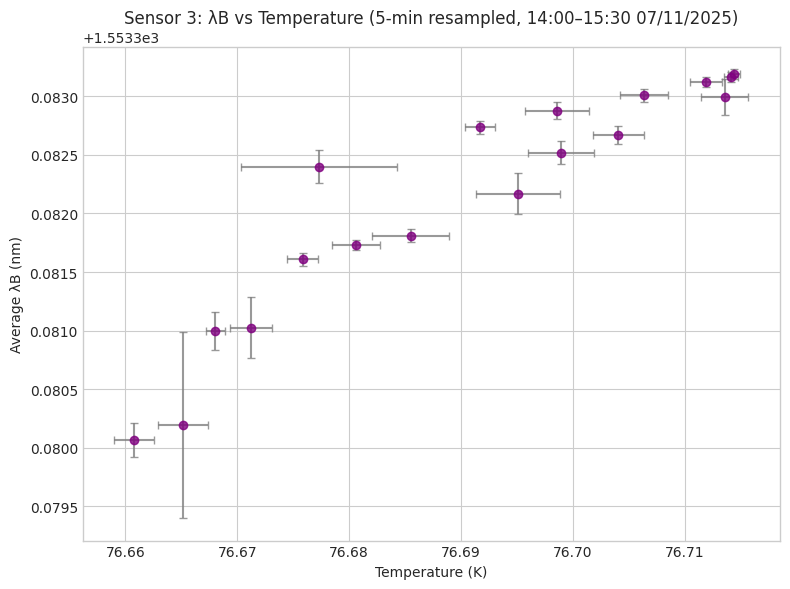

In [14]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root"
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Extract Sensor 3 data ---
peak_times = peak_data["t"][:, 0]           # take first polarization for timestamps
sensor3_pol1 = peak_data["wav"][:, 0, 2]
sensor3_pol2 = peak_data["wav"][:, 1, 2]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 2]

# --- Average the two polarizations ---
sensor3_lambdaB = (sensor3_pol1 + sensor3_pol2) / 2

# --- Convert timestamps to datetime ---
peak_timestamps = pd.to_datetime(peak_times, unit='s')
temp_timestamps = pd.to_datetime(temp_times, unit='s')

start_time = datetime.datetime(2025, 11, 7, 14, 0, 0)
end_time   = datetime.datetime(2025, 11, 7, 15, 30, 0)

# --- ✅ Apply +2 hour correction to peak timestamps ---
time_shift = datetime.timedelta(hours=2)
peak_timestamps = peak_timestamps + time_shift

# Apply time masks
mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)

peak_t_filtered = peak_timestamps[mask_peak]
lambdaB_filtered = sensor3_lambdaB[mask_peak]

temp_t_filtered = temp_timestamps[mask_temp]
temp_filtered = sensor3_temp[mask_temp]

# --- Build DataFrames ---
df_peak = pd.DataFrame({"lambdaB_nm": lambdaB_filtered * 1e9}, index=peak_t_filtered)
df_temp = pd.DataFrame({"temp_K": temp_filtered}, index=temp_t_filtered)

# --- Resample every 5 minutes, compute mean and std ---
peak_resampled = df_peak.resample("5min").agg(["mean","std"])
temp_resampled = df_temp.resample("5min").agg(["mean","std"])

# --- Combine into single DataFrame aligned by time ---
df_combined = pd.concat([peak_resampled, temp_resampled], axis=1).dropna()

# --- Scatter plot λB vs Temperature with error bars ---
plt.figure(figsize=(8,6))
plt.errorbar(
    df_combined["temp_K"]["mean"], 
    df_combined["lambdaB_nm"]["mean"], 
    xerr=df_combined["temp_K"]["std"], 
    yerr=df_combined["lambdaB_nm"]["std"], 
    fmt='o', color='purple', ecolor='gray', capsize=3, alpha=0.8
)
plt.xlabel("Temperature (K)")
plt.ylabel("Average λB (nm)")
plt.title("Sensor 3: λB vs Temperature (5-min resampled, 14:00–15:30 07/11/2025)")
plt.grid(True)
plt.tight_layout()
plt.show()


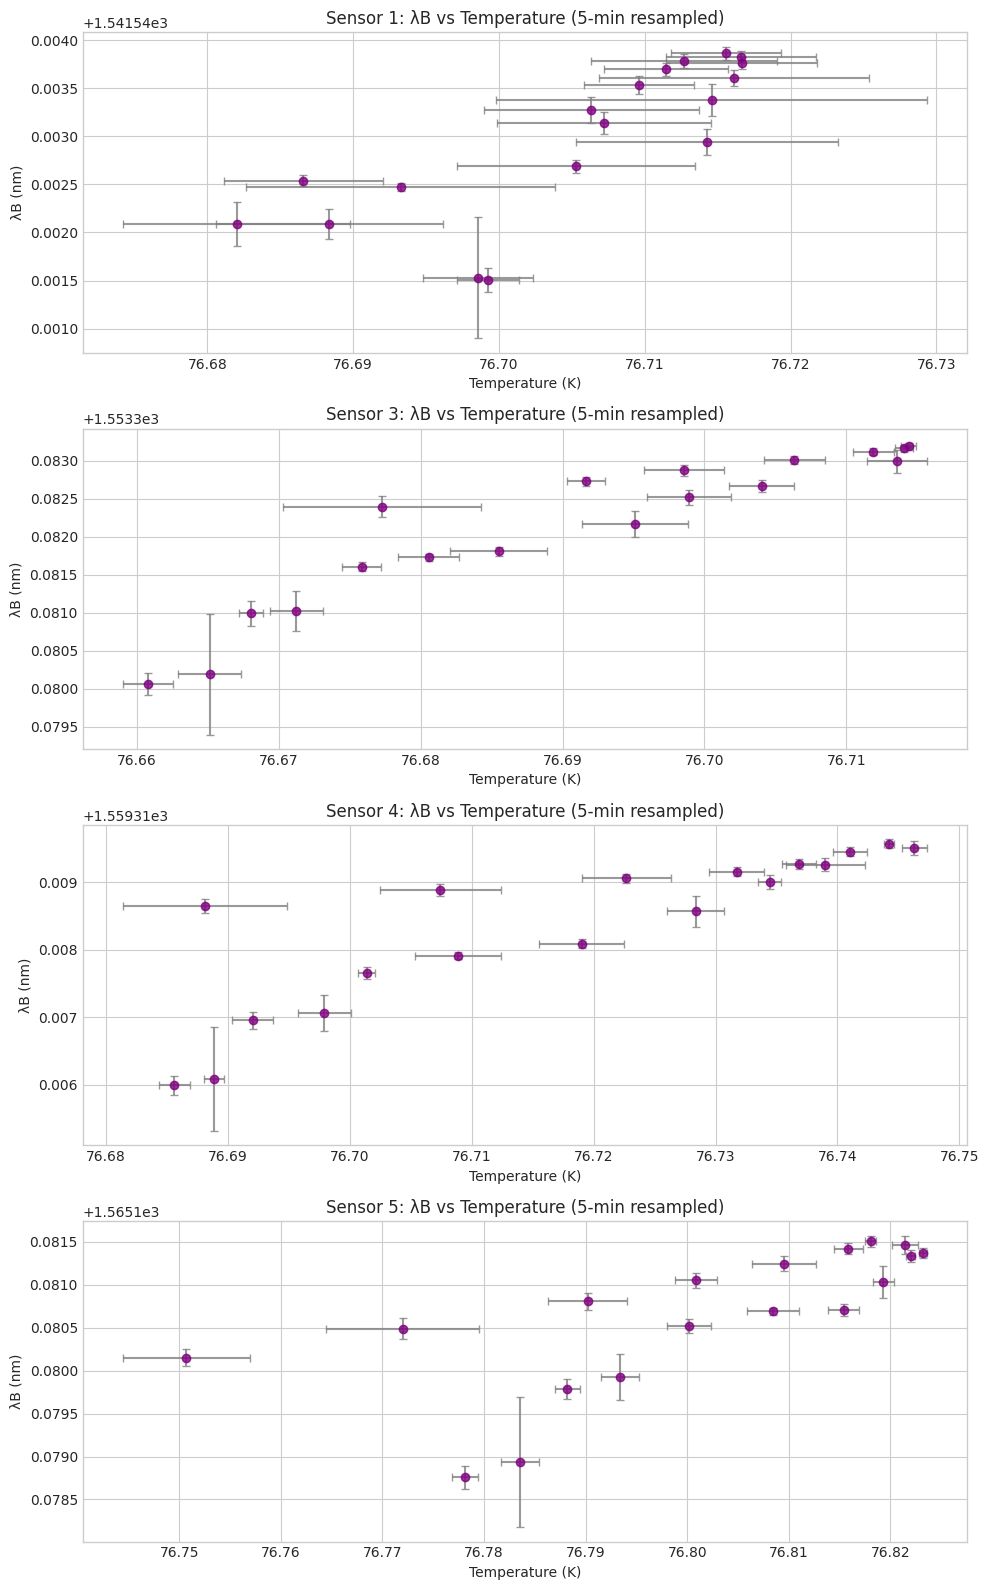

In [15]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root"
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor indices to plot ---
sensors = [0, 2, 3, 4]  # positions: 1,3,4,5

# --- Convert timestamps to datetime ---
peak_timestamps = pd.to_datetime(peak_data["t"][:, 0], unit='s')
temp_timestamps = pd.to_datetime(temp_data["t"], unit='s')

# --- ✅ Apply +2 hour correction to peak timestamps ---
time_shift = datetime.timedelta(hours=2)
peak_timestamps = peak_timestamps + time_shift

# --- Filter time window ---
start_time = datetime.datetime(2025, 11, 7, 14, 0, 0)
end_time   = datetime.datetime(2025, 11, 7, 15, 30, 0)

mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)

peak_t_filtered = peak_timestamps[mask_peak]
temp_t_filtered = temp_timestamps[mask_temp]

# --- Create figure with 4 subplots ---
fig, axes = plt.subplots(4, 1, figsize=(10, 16), sharex=False)

for i, sensor in enumerate(sensors):
    # λB average of two polarizations
    lambdaB = (peak_data["wav"][:, 0, sensor] + peak_data["wav"][:, 1, sensor]) / 2
    lambdaB_filtered = lambdaB[mask_peak]
    
    # Temperature
    temp_sensor = temp_data["temp"][:, sensor]
    temp_filtered = temp_sensor[mask_temp]
    
    # Create DataFrames
    df_peak = pd.DataFrame({"lambdaB_nm": lambdaB_filtered * 1e9}, index=peak_t_filtered)
    df_temp = pd.DataFrame({"temp_K": temp_filtered}, index=temp_t_filtered)
    
    # Resample every 5 minutes and calculate mean & std
    peak_resampled = df_peak.resample("5min").agg(["mean","std"])
    temp_resampled = df_temp.resample("5min").agg(["mean","std"])
    
    # Combine resampled data
    df_combined = pd.concat([peak_resampled, temp_resampled], axis=1).dropna()
    
    # --- Scatter plot λB vs Temperature with error bars ---
    axes[i].errorbar(
        df_combined["temp_K"]["mean"], 
        df_combined["lambdaB_nm"]["mean"], 
        xerr=df_combined["temp_K"]["std"], 
        yerr=df_combined["lambdaB_nm"]["std"], 
        fmt='o', color='purple', ecolor='gray', capsize=3, alpha=0.8
    )
    axes[i].set_xlabel("Temperature (K)")
    axes[i].set_ylabel("λB (nm)")
    axes[i].set_title(f"Sensor {sensor+1}: λB vs Temperature (5-min resampled)")
    axes[i].grid(True)

plt.tight_layout()
plt.show()


---- DATA TIME INTERVALS ----
Peak data (+2h): 2025-11-07 12:24:03.237097979  →  2025-11-07 17:04:45.582643986
Temp data:       2025-11-07 12:22:21  →  2025-11-07 17:03:16
--------------------------------


===== SENSOR 1 =====
λB range: 1541540.3–1541544.2 pm
T range:  76.67–76.75 K
Fit data points: 45
x mean ± std: 76.705 ± 0.012 K
y mean ± std: 1541543.0 ± 0.8 pm
Slope = 5.1655e+01 pm/K
Intercept = 1537581.01 pm

===== SENSOR 3 =====
λB range: 1553378.7–1553383.6 pm
T range:  76.66–76.72 K
Fit data points: 45
x mean ± std: 76.691 ± 0.018 K
y mean ± std: 1553382.1 ± 1.0 pm
Slope = 4.1233e+01 pm/K
Intercept = 1550220.11 pm

===== SENSOR 4 =====
λB range: 1559314.5–1559320.1 pm
T range:  76.68–76.75 K
Fit data points: 45
x mean ± std: 76.717 ± 0.021 K
y mean ± std: 1559318.3 ± 1.1 pm
Slope = 3.9194e+01 pm/K
Intercept = 1556311.58 pm

===== SENSOR 5 =====
λB range: 1565177.4–1565181.9 pm
T range:  76.74–76.82 K
Fit data points: 45
x mean ± std: 76.801 ± 0.020 K
y mean ± std: 1565180.6 ±

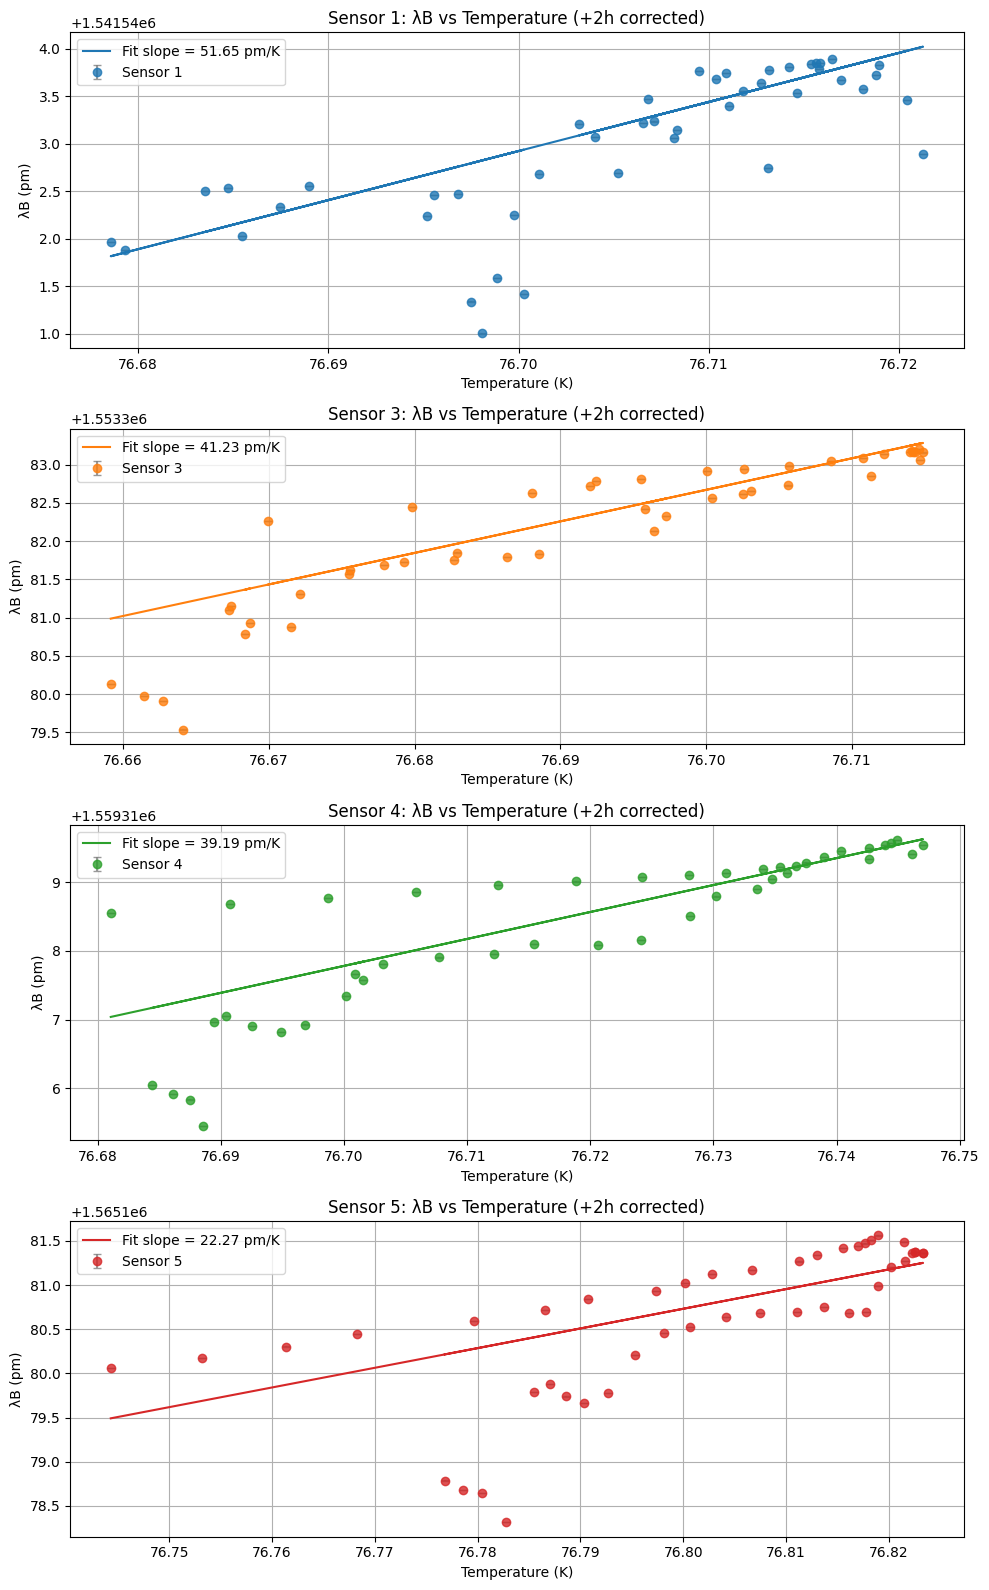

In [2]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root"
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensors to analyze (1,3,4,5) ---
sensors = [0, 2, 3, 4]

# --- Convert timestamps ---
peak_times = pd.to_datetime(peak_data["t"][:, 0], unit='s')
temp_times = pd.to_datetime(temp_data["t"], unit='s')

# --- ✅ Apply +2 hour correction to peak timestamps ---
time_shift = datetime.timedelta(hours=2)
peak_times = peak_times + time_shift

# --- Print data intervals for sanity check ---
print("---- DATA TIME INTERVALS ----")
print(f"Peak data (+2h): {peak_times.min()}  →  {peak_times.max()}")
print(f"Temp data:       {temp_times.min()}  →  {temp_times.max()}")
print("--------------------------------\n")

# --- Time window ---
start_time = datetime.datetime(2025, 11, 7, 14, 0, 0)
end_time   = datetime.datetime(2025, 11, 7, 15, 30, 0)

mask_peak = (peak_times >= start_time) & (peak_times <= end_time)
mask_temp = (temp_times >= start_time) & (temp_times <= end_time)

peak_t_filtered = peak_times[mask_peak]
temp_t_filtered = temp_times[mask_temp]

# --- Fixed colors per sensor ---
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

# --- Create figure ---
fig, axes = plt.subplots(len(sensors), 1, figsize=(10, 16))

for i, sensor in enumerate(sensors):
    print(f"\n===== SENSOR {sensor+1} =====")
    
    # Average λB from both polarizations
    lambdaB_m = (peak_data["wav"][:, 0, sensor] + peak_data["wav"][:, 1, sensor]) / 2  # meters
    lambdaB_nm = lambdaB_m * 1e9  # nanometers
    lambdaB_pm = lambdaB_nm * 1e3  # picometers
    lambdaB_filtered = lambdaB_pm[mask_peak]
    
    # --- FILTRO: descartar valores 0 o negativos ---
    valid_mask = lambdaB_filtered > 0
    lambdaB_filtered = lambdaB_filtered[valid_mask]
    peak_t_valid = peak_t_filtered[valid_mask]
    
    # Quick check of magnitude
    print(f"λB range: {lambdaB_filtered.min():.1f}–{lambdaB_filtered.max():.1f} pm")
    
    # Temperature
    temp_sensor = temp_data["temp"][:, sensor]
    temp_filtered = temp_sensor[mask_temp]
    print(f"T range:  {temp_filtered.min():.2f}–{temp_filtered.max():.2f} K")

    # DataFrames
    df_peak = pd.DataFrame({"lambdaB_pm": lambdaB_filtered}, index=peak_t_valid)
    df_temp = pd.DataFrame({"temp_K": temp_filtered}, index=temp_t_filtered)
    
    # Resample every 2 minutes → mean & std
    peak_resampled = df_peak.resample("2min").agg(['mean','std'])
    temp_resampled = df_temp.resample("2min").agg(['mean','std'])
    
    # Standard error of the mean
    peak_resampled['lambdaB_pm','se'] = peak_resampled['lambdaB_pm','std'] / np.sqrt(df_peak.resample("2min").count()['lambdaB_pm'])
    temp_resampled['temp_K','se'] = temp_resampled['temp_K','std'] / np.sqrt(df_temp.resample("2min").count()['temp_K'])
    
    # Merge and drop NaN
    df_combined = pd.concat([peak_resampled, temp_resampled], axis=1).dropna()
    
    # --- Weighted linear fit (x=Temp (K), y=λB (pm)) ---
    x = df_combined['temp_K','mean'].values
    y = df_combined['lambdaB_pm','mean'].values
    yerr = df_combined['lambdaB_pm','se'].values

    print(f"Fit data points: {len(x)}")
    print(f"x mean ± std: {np.mean(x):.3f} ± {np.std(x):.3f} K")
    print(f"y mean ± std: {np.mean(y):.1f} ± {np.std(y):.1f} pm")
    
    w = 1 / yerr**2 if np.all(yerr > 0) else None
    if w is not None:
        slope, intercept = np.polyfit(x, y, 1, w=w)
    else:
        slope, intercept = np.polyfit(x, y, 1)
    
    print(f"Slope = {slope:.4e} pm/K")
    print(f"Intercept = {intercept:.2f} pm")
    
    # Plot
    axes[i].errorbar(x, y, yerr=yerr, fmt='o', color=colors[i], ecolor='gray', capsize=3, alpha=0.8, label=f"Sensor {sensor+1}")
    axes[i].plot(x, slope*x + intercept, '-', color=colors[i], label=f"Fit slope = {slope:.2f} pm/K")
    
    axes[i].set_xlabel("Temperature (K)")
    axes[i].set_ylabel("λB (pm)")
    axes[i].set_title(f"Sensor {sensor+1}: λB vs Temperature (+2h corrected)")
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
plt.show()

---- DATA TIME INTERVALS ----
Peak data (+2h): 2025-11-07 12:22:48.237097979  →  2025-11-07 17:03:30.582643986
Temp data:       2025-11-07 12:22:21  →  2025-11-07 17:03:16
--------------------------------


===== SENSOR 1 =====
λB range: 1541112.4–1545961.6 pm
T range:  124.79–295.97 K
Fit data points: 149
x mean ± std: 261.767 ± 32.374 K
y mean ± std: 1544396.6 ± 853.9 pm
Slope = 4.8868e+01 pm/K
Intercept = 1531326.66 pm

===== SENSOR 3 =====
λB range: 1553578.9–1557582.8 pm
T range:  83.44–295.79 K
Fit data points: 149
x mean ± std: 133.863 ± 67.247 K
y mean ± std: 1554426.9 ± 1109.7 pm
Slope = 1.7479e+01 pm/K
Intercept = 1552240.14 pm

===== SENSOR 4 =====
λB range: 780438.0–1563403.5 pm
T range:  79.33–295.61 K
Fit data points: 149
x mean ± std: 121.149 ± 64.215 K
y mean ± std: 1560124.0 ± 1112.9 pm
Slope = 1.7151e+01 pm/K
Intercept = 1558165.97 pm

===== SENSOR 5 =====
λB range: 783015.1–1568252.6 pm
T range:  78.87–295.69 K
Fit data points: 137
x mean ± std: 105.049 ± 31.115 K
y 

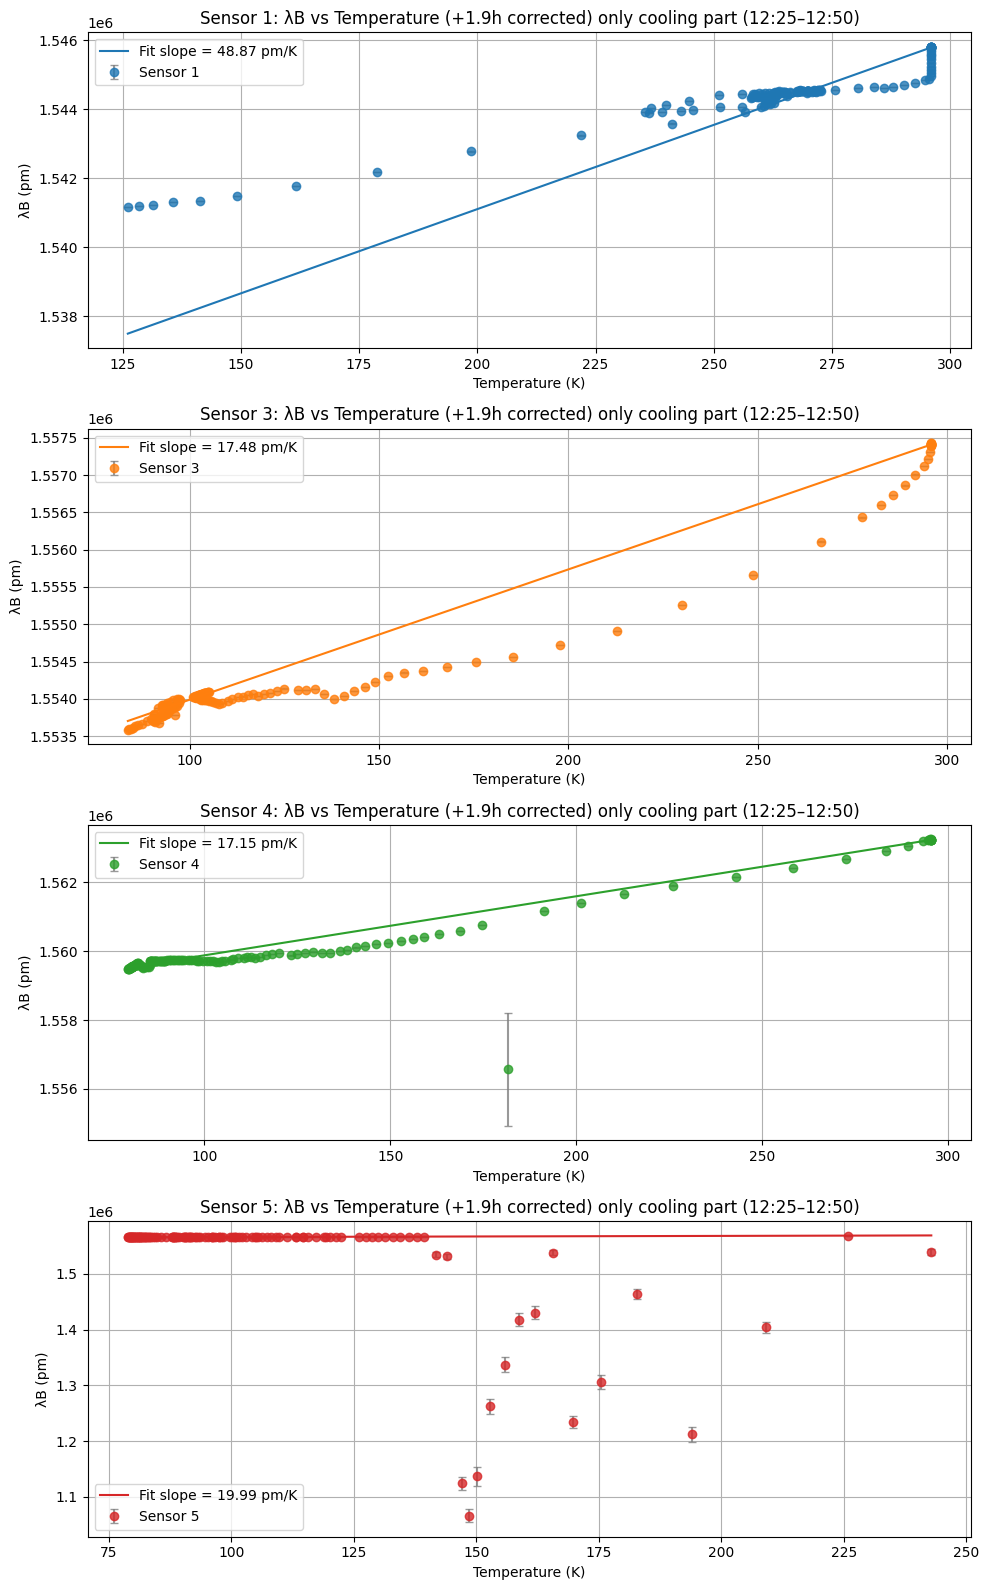

In [4]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root"
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensors to analyze (1,3,4,5) ---
sensors = [0, 2, 3, 4]

# --- Convert timestamps ---
peak_times = pd.to_datetime(peak_data["t"][:, 0], unit='s')
temp_times = pd.to_datetime(temp_data["t"], unit='s')

# --- ✅ Apply +2 hour correction to peak timestamps ---
time_shift = datetime.timedelta(hours=2) - datetime.timedelta(minutes=1.25)
peak_times = peak_times + time_shift

# --- Print data intervals for sanity check ---
print("---- DATA TIME INTERVALS ----")
print(f"Peak data (+2h): {peak_times.min()}  →  {peak_times.max()}")
print(f"Temp data:       {temp_times.min()}  →  {temp_times.max()}")
print("--------------------------------\n")

# --- Time window ---
start_time = datetime.datetime(2025, 11, 7, 12, 25, 0)
end_time   = datetime.datetime(2025, 11, 7, 12, 50, 0)

mask_peak = (peak_times >= start_time) & (peak_times <= end_time)
mask_temp = (temp_times >= start_time) & (temp_times <= end_time)

peak_t_filtered = peak_times[mask_peak]
temp_t_filtered = temp_times[mask_temp]

# --- Fixed colors per sensor ---
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

# --- Create figure ---
fig, axes = plt.subplots(len(sensors), 1, figsize=(10, 16))

for i, sensor in enumerate(sensors):
    print(f"\n===== SENSOR {sensor+1} =====")
    
    # Average λB from both polarizations
    lambdaB_m = (peak_data["wav"][:, 0, sensor] + peak_data["wav"][:, 1, sensor]) / 2  # meters
    lambdaB_nm = lambdaB_m * 1e9  # nanometers
    lambdaB_pm = lambdaB_nm * 1e3  # picometers
    lambdaB_filtered = lambdaB_pm[mask_peak]
    
    # --- FILTRO: descartar valores 0 o negativos ---
    valid_mask = lambdaB_filtered > 0
    lambdaB_filtered = lambdaB_filtered[valid_mask]
    peak_t_valid = peak_t_filtered[valid_mask]
    
    # Quick check of magnitude
    print(f"λB range: {lambdaB_filtered.min():.1f}–{lambdaB_filtered.max():.1f} pm")
    
    # Temperature
    temp_sensor = temp_data["temp"][:, sensor]
    temp_filtered = temp_sensor[mask_temp]
    print(f"T range:  {temp_filtered.min():.2f}–{temp_filtered.max():.2f} K")

    # DataFrames
    df_peak = pd.DataFrame({"lambdaB_pm": lambdaB_filtered}, index=peak_t_valid)
    df_temp = pd.DataFrame({"temp_K": temp_filtered}, index=temp_t_filtered)
    
    # Resample every 1 minute → mean & std
    peak_resampled = df_peak.resample("10s").agg(['mean','std'])
    temp_resampled = df_temp.resample("10s").agg(['mean','std'])
    
    # Standard error of the mean
    peak_resampled['lambdaB_pm','se'] = peak_resampled['lambdaB_pm','std'] / np.sqrt(df_peak.resample("10s").count()['lambdaB_pm'])
    temp_resampled['temp_K','se'] = temp_resampled['temp_K','std'] / np.sqrt(df_temp.resample("10s").count()['temp_K'])
    
    # Merge and drop NaN
    df_combined = pd.concat([peak_resampled, temp_resampled], axis=1).dropna()
    
    # --- Weighted linear fit (x=Temp (K), y=λB (pm)) ---
    x = df_combined['temp_K','mean'].values
    y = df_combined['lambdaB_pm','mean'].values
    yerr = df_combined['lambdaB_pm','se'].values

    print(f"Fit data points: {len(x)}")
    print(f"x mean ± std: {np.mean(x):.3f} ± {np.std(x):.3f} K")
    print(f"y mean ± std: {np.mean(y):.1f} ± {np.std(y):.1f} pm")
    
    w = 1 / yerr**2 if np.all(yerr > 0) else None
    if w is not None:
        slope, intercept = np.polyfit(x, y, 1, w=w)
    else:
        slope, intercept = np.polyfit(x, y, 1)
    
    print(f"Slope = {slope:.4e} pm/K")
    print(f"Intercept = {intercept:.2f} pm")
    
    # Plot
    axes[i].errorbar(x, y, yerr=yerr, fmt='o', color=colors[i], ecolor='gray', capsize=3, alpha=0.8, label=f"Sensor {sensor+1}")
    axes[i].plot(x, slope*x + intercept, '-', color=colors[i], label=f"Fit slope = {slope:.2f} pm/K")
    
    axes[i].set_xlabel("Temperature (K)")
    axes[i].set_ylabel("λB (pm)")
    axes[i].set_title(f"Sensor {sensor+1}: λB vs Temperature (+1.9h corrected) only cooling part (12:25–12:50)")
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
plt.show()

---- DATA TIME INTERVALS ----
Peak data (+2h): 2025-11-07 12:22:48.237097979  →  2025-11-07 17:03:30.582643986
Temp data:       2025-11-07 12:22:21  →  2025-11-07 17:03:16
--------------------------------


===== SENSOR 1 =====
λB range: 1541112.4–1544699.1 pm
T range:  124.79–288.81 K
Fit data points: 125
x mean ± std: 255.291 ± 31.443 K
y mean ± std: 1544193.4 ± 764.0 pm
Slope = 1.6309e+01 pm/K
Intercept = 1540116.67 pm

===== SENSOR 3 =====
λB range: 1553578.9–1554677.4 pm
T range:  83.44–190.42 K
Fit data points: 125
x mean ± std: 105.811 ± 18.872 K
y mean ± std: 1553969.0 ± 175.9 pm
Slope = 2.4961e+01 pm/K
Intercept = 1551480.13 pm

===== SENSOR 4 =====
λB range: 1559473.5–1560482.6 pm
T range:  79.33–160.47 K
Fit data points: 125
x mean ± std: 95.494 ± 19.227 K
y mean ± std: 1559721.1 ± 174.9 pm
Slope = 3.5499e+01 pm/K
Intercept = 1556686.88 pm

===== SENSOR 5 =====
λB range: 783015.1–1566219.2 pm
T range:  78.87–151.44 K
Fit data points: 125
x mean ± std: 97.574 ± 18.645 K
y mea

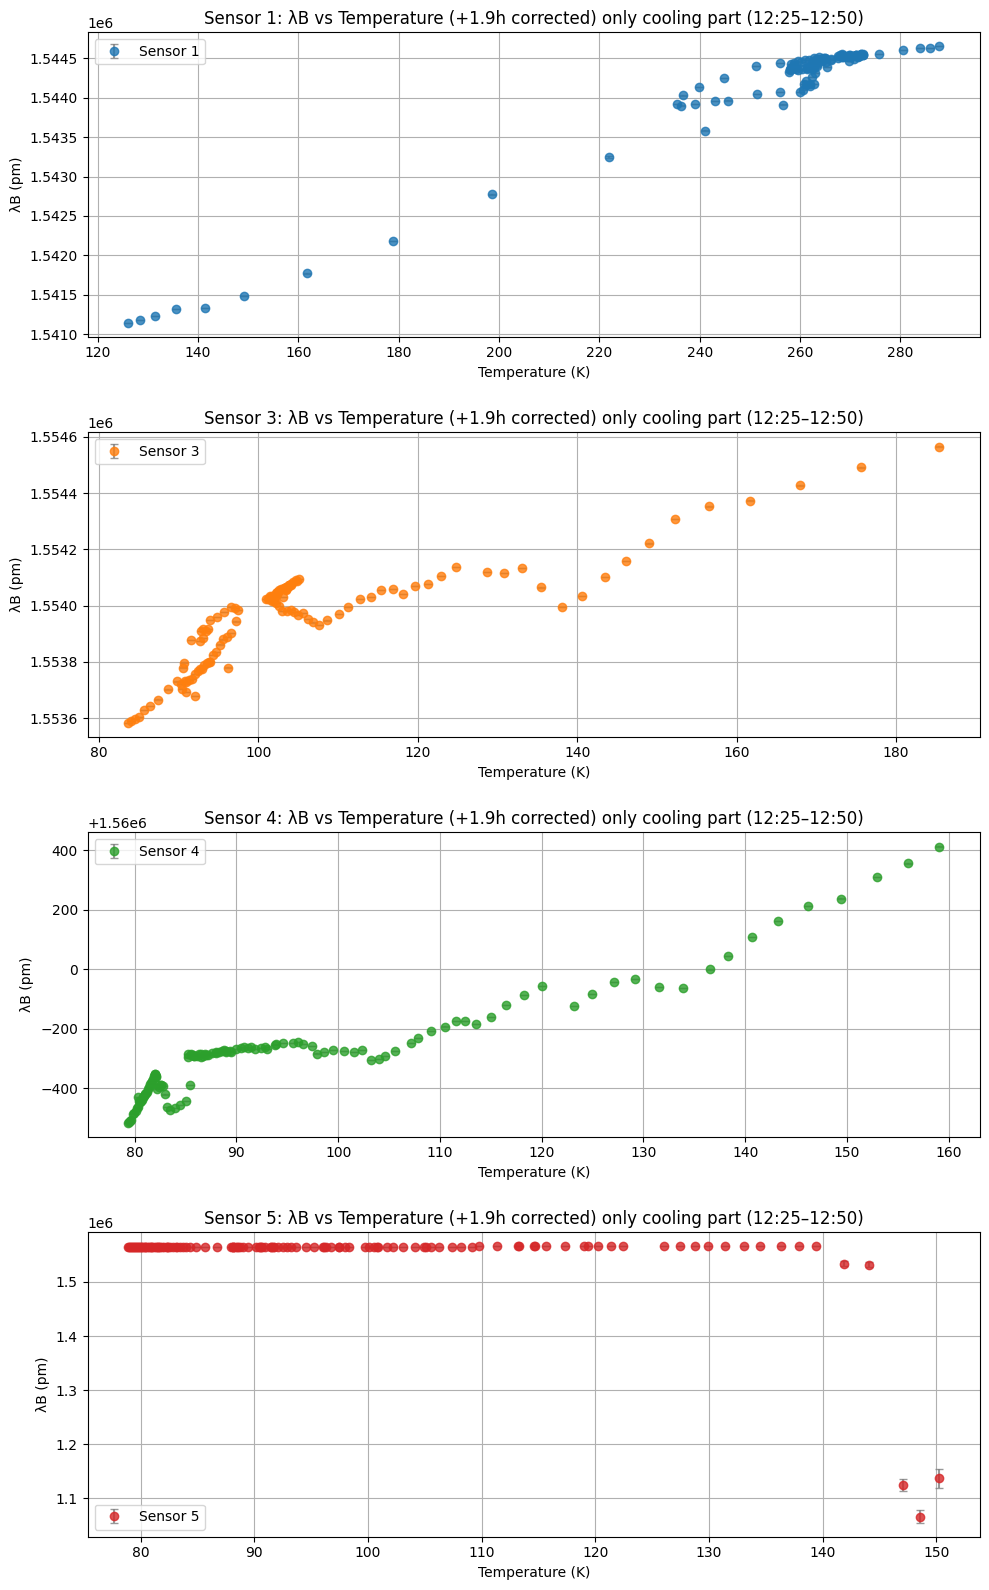

In [5]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root"
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensors to analyze (1,3,4,5) ---
sensors = [0, 2, 3, 4]

# --- Convert timestamps ---
peak_times = pd.to_datetime(peak_data["t"][:, 0], unit='s')
temp_times = pd.to_datetime(temp_data["t"], unit='s')

# --- ✅ Apply +2 hour correction to peak timestamps ---
time_shift = datetime.timedelta(hours=2) - datetime.timedelta(minutes=1.25)
peak_times = peak_times + time_shift

# --- Print data intervals for sanity check ---
print("---- DATA TIME INTERVALS ----")
print(f"Peak data (+2h): {peak_times.min()}  →  {peak_times.max()}")
print(f"Temp data:       {temp_times.min()}  →  {temp_times.max()}")
print("--------------------------------\n")

# --- Time window ---
start_time = datetime.datetime(2025, 11, 7, 12, 29, 0)
end_time   = datetime.datetime(2025, 11, 7, 12, 50, 0)

mask_peak = (peak_times >= start_time) & (peak_times <= end_time)
mask_temp = (temp_times >= start_time) & (temp_times <= end_time)

peak_t_filtered = peak_times[mask_peak]
temp_t_filtered = temp_times[mask_temp]

# --- Fixed colors per sensor ---
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

# --- Create figure ---
fig, axes = plt.subplots(len(sensors), 1, figsize=(10, 16))

for i, sensor in enumerate(sensors):
    print(f"\n===== SENSOR {sensor+1} =====")
    
    # Average λB from both polarizations
    lambdaB_m = (peak_data["wav"][:, 0, sensor] + peak_data["wav"][:, 1, sensor]) / 2  # meters
    lambdaB_nm = lambdaB_m * 1e9  # nanometers
    lambdaB_pm = lambdaB_nm * 1e3  # picometers
    lambdaB_filtered = lambdaB_pm[mask_peak]
    
    # --- FILTRO: descartar valores 0 o negativos ---
    valid_mask = lambdaB_filtered > 0
    lambdaB_filtered = lambdaB_filtered[valid_mask]
    peak_t_valid = peak_t_filtered[valid_mask]
    
    # Quick check of magnitude
    print(f"λB range: {lambdaB_filtered.min():.1f}–{lambdaB_filtered.max():.1f} pm")
    
    # Temperature
    temp_sensor = temp_data["temp"][:, sensor]
    temp_filtered = temp_sensor[mask_temp]
    print(f"T range:  {temp_filtered.min():.2f}–{temp_filtered.max():.2f} K")

    # DataFrames
    df_peak = pd.DataFrame({"lambdaB_pm": lambdaB_filtered}, index=peak_t_valid)
    df_temp = pd.DataFrame({"temp_K": temp_filtered}, index=temp_t_filtered)
    
    # Resample every 10s  → mean & std
    peak_resampled = df_peak.resample("10s").agg(['mean','std'])
    temp_resampled = df_temp.resample("10s").agg(['mean','std'])
    
    # Standard error of the mean
    peak_resampled['lambdaB_pm','se'] = peak_resampled['lambdaB_pm','std'] / np.sqrt(df_peak.resample("10s").count()['lambdaB_pm'])
    temp_resampled['temp_K','se'] = temp_resampled['temp_K','std'] / np.sqrt(df_temp.resample("10s").count()['temp_K'])
    
    # Merge and drop NaN
    df_combined = pd.concat([peak_resampled, temp_resampled], axis=1).dropna()
    
    # --- Weighted linear fit (x=Temp (K), y=λB (pm)) ---
    x = df_combined['temp_K','mean'].values
    y = df_combined['lambdaB_pm','mean'].values
    yerr = df_combined['lambdaB_pm','se'].values

    print(f"Fit data points: {len(x)}")
    print(f"x mean ± std: {np.mean(x):.3f} ± {np.std(x):.3f} K")
    print(f"y mean ± std: {np.mean(y):.1f} ± {np.std(y):.1f} pm")
    
    w = 1 / yerr**2 if np.all(yerr > 0) else None
    if w is not None:
        slope, intercept = np.polyfit(x, y, 1, w=w)
    else:
        slope, intercept = np.polyfit(x, y, 1)
    
    print(f"Slope = {slope:.4e} pm/K")
    print(f"Intercept = {intercept:.2f} pm")
    
    # Plot
    axes[i].errorbar(x, y, yerr=yerr, fmt='o', color=colors[i], ecolor='gray', capsize=3, alpha=0.8, label=f"Sensor {sensor+1}")
    #axes[i].plot(x, slope*x + intercept, '-', color=colors[i], label=f"Fit slope = {slope:.2f} pm/K")
    
    axes[i].set_xlabel("Temperature (K)")
    axes[i].set_ylabel("λB (pm)")
    axes[i].set_title(f"Sensor {sensor+1}: λB vs Temperature (+1.9h corrected) only cooling part (12:25–12:50)")
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
plt.show()

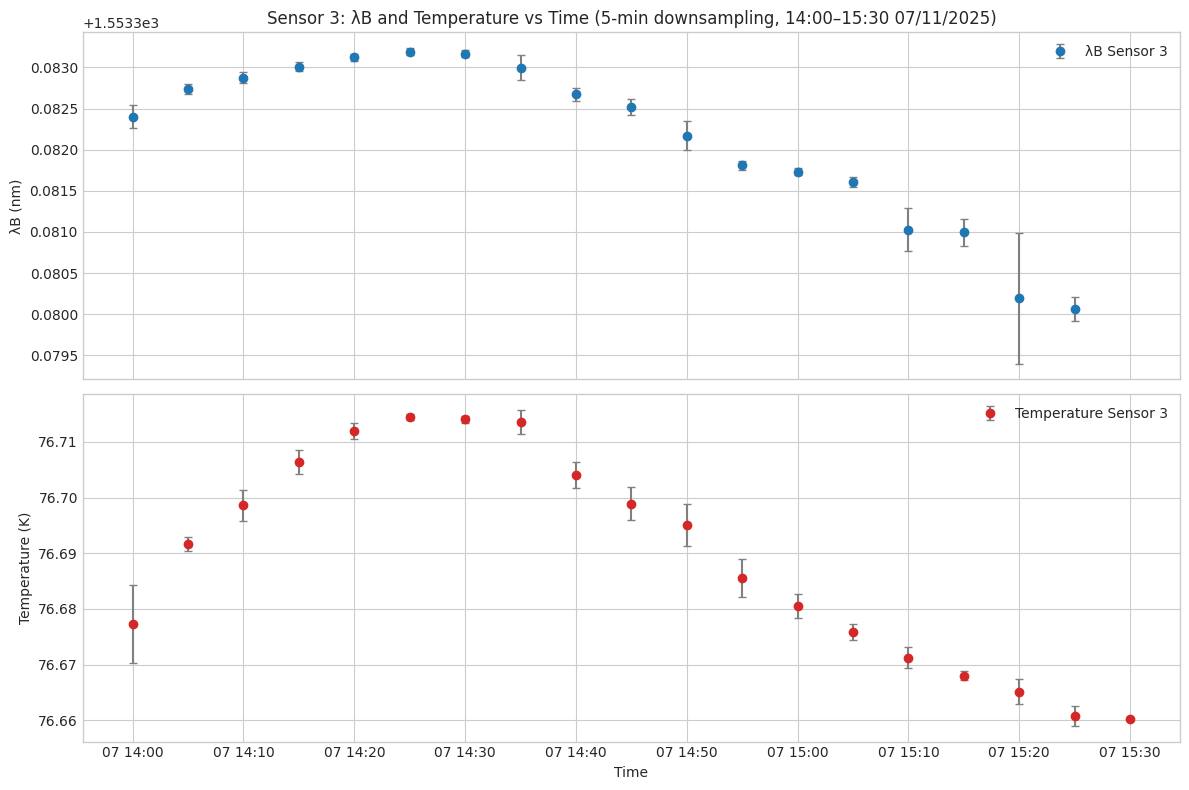

In [ ]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root"
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Extract Sensor 3 data ---
peak_times = peak_data["t"][:, 0]           # first polarization timestamps
sensor3_pol1 = peak_data["wav"][:, 0, 2]
sensor3_pol2 = peak_data["wav"][:, 1, 2]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 2]

# --- Average the two polarizations ---
sensor3_lambdaB = (sensor3_pol1 + sensor3_pol2) / 2

# --- Convert timestamps to datetime ---
peak_timestamps = pd.to_datetime(peak_times, unit='s')
temp_timestamps = pd.to_datetime(temp_times, unit='s')

# --- ✅ Apply +2 hour correction to peak timestamps ---
time_shift = datetime.timedelta(hours=2) - datetime.timedelta(minutes=1.25)
peak_timestamps = peak_timestamps + time_shift

start_time = datetime.datetime(2025, 11, 7, 14, 0, 0)
end_time   = datetime.datetime(2025, 11, 7, 15, 30, 0)

mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)

peak_t_filtered = peak_timestamps[mask_peak]
lambdaB_filtered = sensor3_lambdaB[mask_peak]

temp_t_filtered = temp_timestamps[mask_temp]
temp_filtered = sensor3_temp[mask_temp]

# --- Create DataFrames ---
df_peak = pd.DataFrame({"lambdaB_nm": lambdaB_filtered * 1e9}, index=peak_t_filtered)
df_temp = pd.DataFrame({"temp_K": temp_filtered}, index=temp_t_filtered)

# --- Resample every 5 minutes, calculate mean and std ---
peak_resampled = df_peak.resample("5min").agg(["mean","std"])
temp_resampled = df_temp.resample("5min").agg(["mean","std"])

# --- Plot in two subplots ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# Top subplot: λB vs time with error bars
ax1.errorbar(peak_resampled.index, peak_resampled["lambdaB_nm"]["mean"],
             yerr=peak_resampled["lambdaB_nm"]["std"], fmt='o', color="tab:blue",
             ecolor='gray', capsize=3, label="λB Sensor 3")
ax1.set_ylabel("λB (nm)")
ax1.set_title("Sensor 3: λB and Temperature vs Time (5-min downsampling, 14:00–15:30 07/11/2025)")
ax1.grid(True)
ax1.legend()

# Bottom subplot: Temperature vs time with error bars
ax2.errorbar(temp_resampled.index, temp_resampled["temp_K"]["mean"],
             yerr=temp_resampled["temp_K"]["std"], fmt='o', color="tab:red",
             ecolor='gray', capsize=3, label="Temperature Sensor 3")
ax2.set_xlabel("Time")
ax2.set_ylabel("Temperature (K)")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()


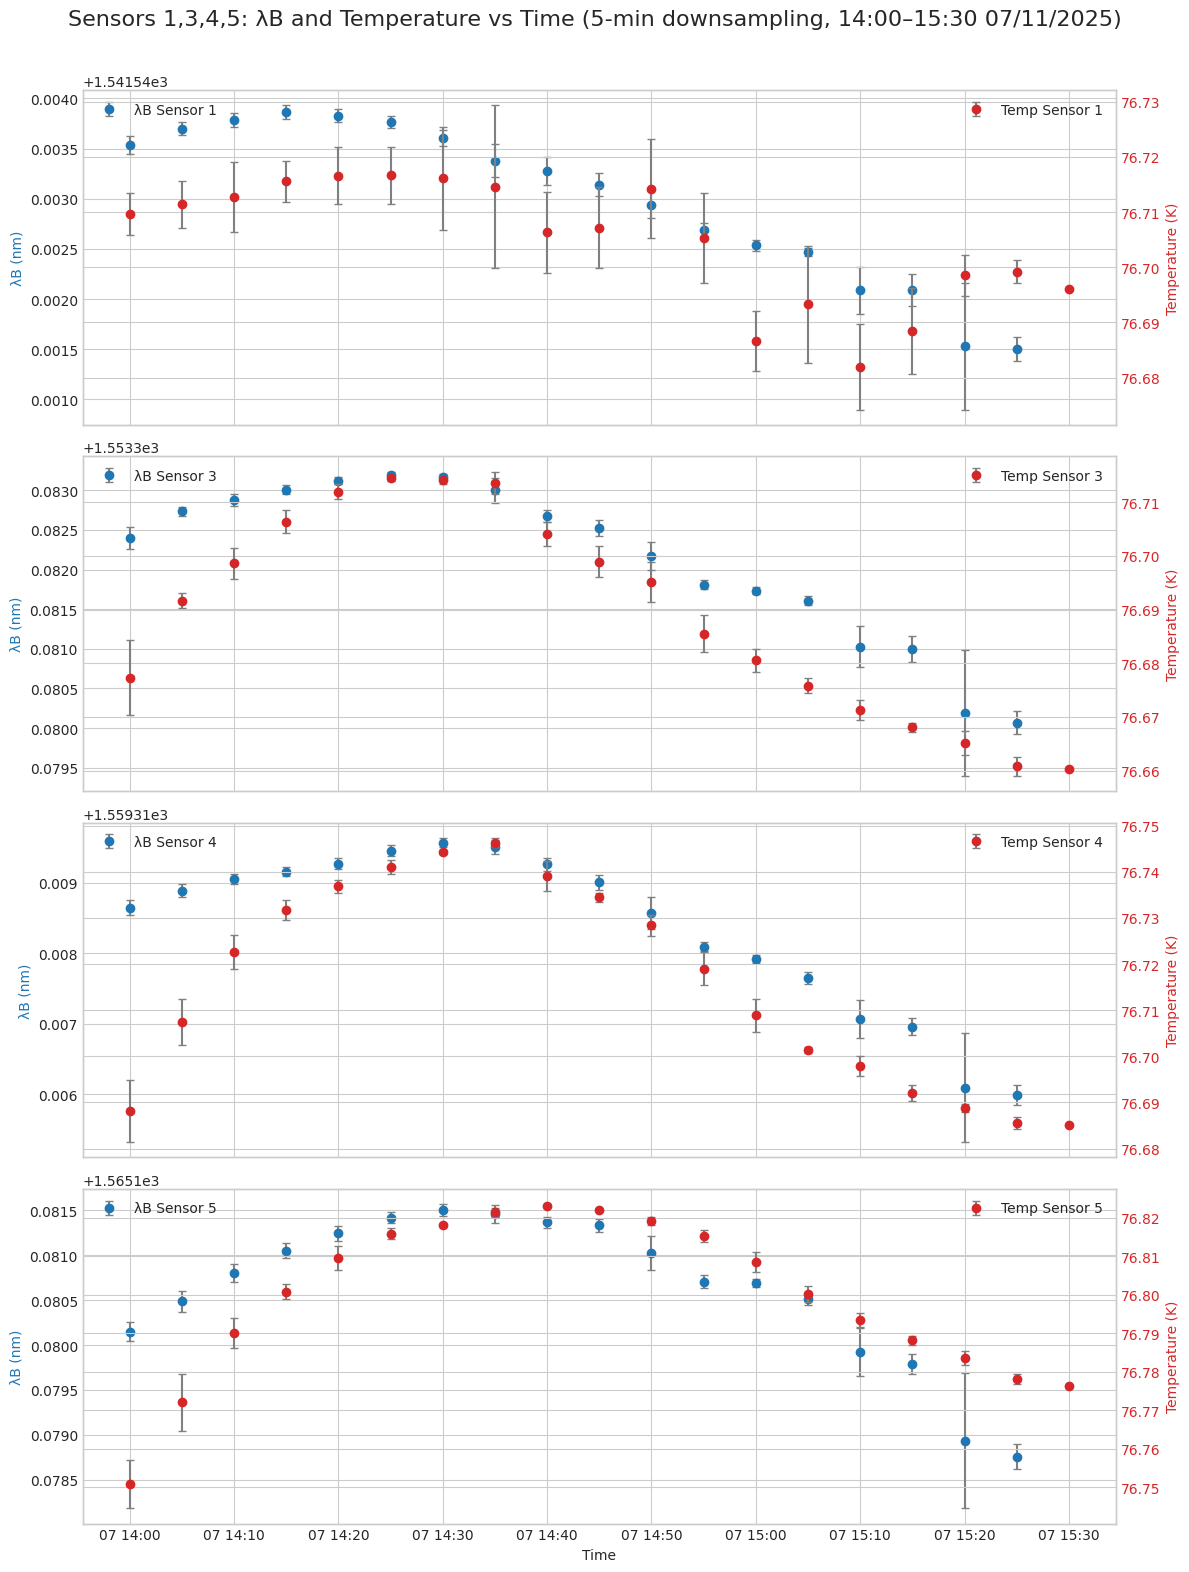

In [18]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root"
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor indices to plot ---
sensors = [0, 2, 3, 4]  # positions: 1,3,4,5

# --- Convert timestamps to datetime ---
peak_timestamps = pd.to_datetime(peak_data["t"][:, 0], unit='s')
temp_timestamps = pd.to_datetime(temp_data["t"], unit='s')

# --- ✅ Apply +2 hour correction to peak timestamps ---
time_shift = datetime.timedelta(hours=2)
peak_timestamps = peak_timestamps + time_shift


# --- Filter time window ---
start_time = datetime.datetime(2025, 11, 7, 14, 0, 0)
end_time   = datetime.datetime(2025, 11, 7, 15, 30, 0)

mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)

peak_t_filtered = peak_timestamps[mask_peak]
temp_t_filtered = temp_timestamps[mask_temp]

# --- Create figure with 4 subplots ---
fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

for i, sensor in enumerate(sensors):
    # λB average of two polarizations
    lambdaB = (peak_data["wav"][:, 0, sensor] + peak_data["wav"][:, 1, sensor]) / 2
    lambdaB_filtered = lambdaB[mask_peak]
    
    # Temperature
    temp_sensor = temp_data["temp"][:, sensor]
    temp_filtered = temp_sensor[mask_temp]
    
    # Create DataFrames
    df_peak = pd.DataFrame({"lambdaB_nm": lambdaB_filtered * 1e9}, index=peak_t_filtered)
    df_temp = pd.DataFrame({"temp_K": temp_filtered}, index=temp_t_filtered)
    
    # Resample every 5 minutes and calculate mean & std
    peak_resampled = df_peak.resample("5min").agg(["mean","std"])
    temp_resampled = df_temp.resample("5min").agg(["mean","std"])
    
    # --- Plot λB with error bars ---
    axes[i].errorbar(peak_resampled.index, peak_resampled["lambdaB_nm"]["mean"],
                     yerr=peak_resampled["lambdaB_nm"]["std"], fmt='o', color="tab:blue",
                     ecolor='gray', capsize=3, label=f"λB Sensor {sensor+1}")
    axes[i].set_ylabel("λB (nm)", color="tab:blue")
    axes[i].grid(True)
    axes[i].legend(loc="upper left")
    
    # --- Plot Temperature with error bars on secondary y-axis ---
    ax2 = axes[i].twinx()
    ax2.errorbar(temp_resampled.index, temp_resampled["temp_K"]["mean"],
                 yerr=temp_resampled["temp_K"]["std"], fmt='o', color="tab:red",
                 ecolor='gray', capsize=3, label=f"Temp Sensor {sensor+1}")
    ax2.set_ylabel("Temperature (K)", color="tab:red")
    ax2.tick_params(axis='y', labelcolor="tab:red")
    ax2.legend(loc="upper right")

axes[-1].set_xlabel("Time")
plt.suptitle("Sensors 1,3,4,5: λB and Temperature vs Time (5-min downsampling, 14:00–15:30 07/11/2025)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


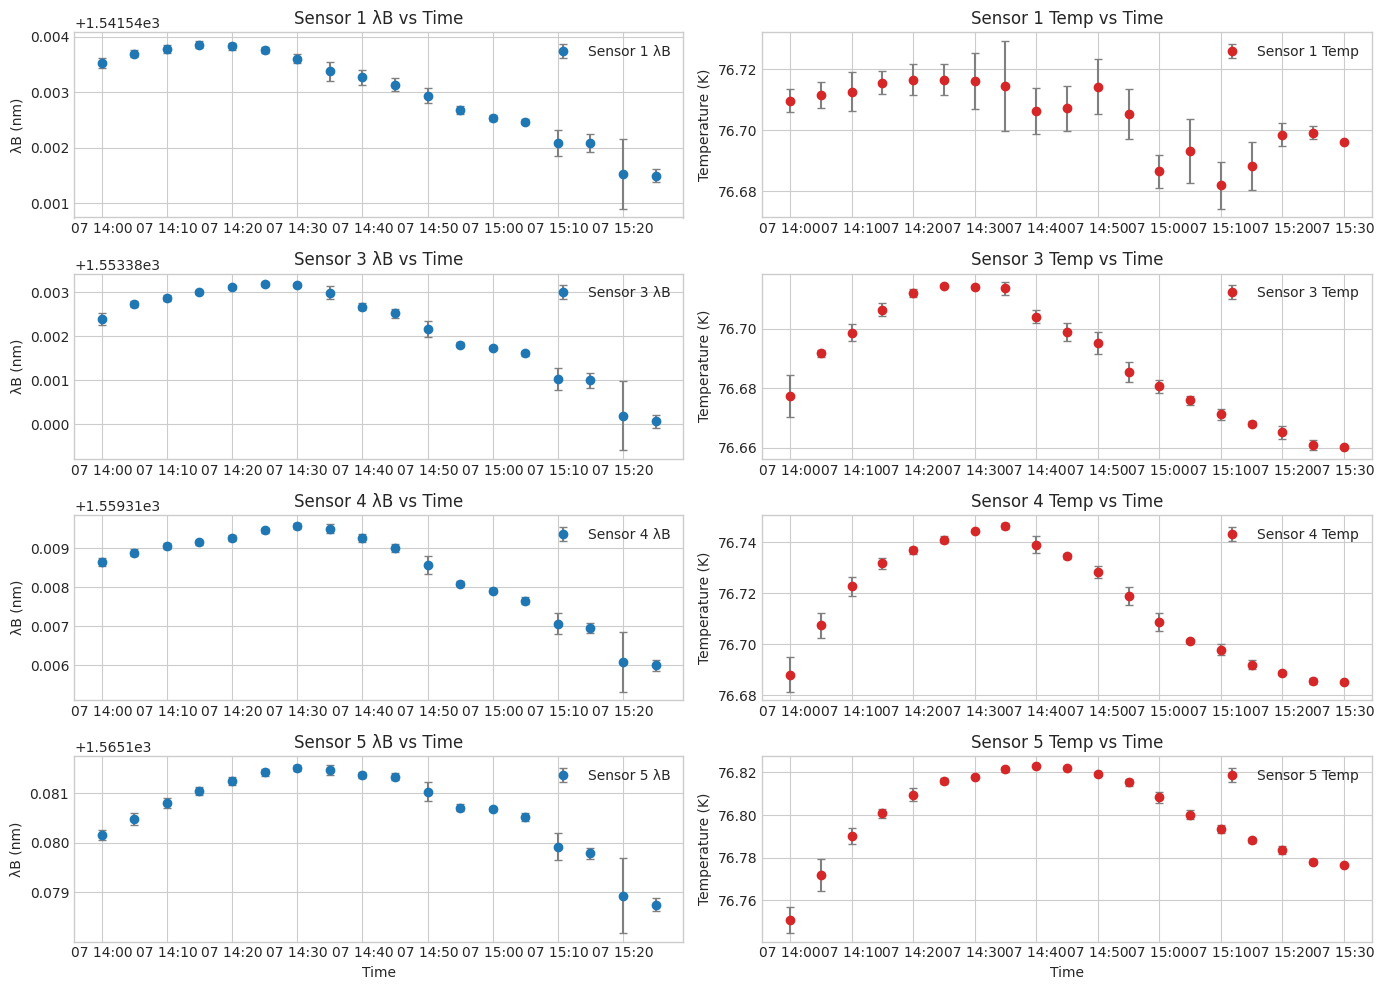

In [19]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root"
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor indices to plot (0-based, skipping sensor 2) ---
sensor_indices = [0, 2, 3, 4]  # sensors 1,3,4,5

# --- Convert times to datetime ---
peak_timestamps = pd.to_datetime(peak_data["t"][:, 0], unit='s')
temp_timestamps = pd.to_datetime(temp_data["t"], unit='s')
# --- ✅ Apply +2 hour correction to peak timestamps ---
time_shift = datetime.timedelta(hours=2)
peak_timestamps = peak_timestamps + time_shift

# --- Time window ---
start_time = datetime.datetime(2025, 11, 7, 14, 0, 0)
end_time   = datetime.datetime(2025, 11, 7, 15, 30, 0)

# --- Create figure ---
fig, axes = plt.subplots(len(sensor_indices), 2, figsize=(14, 10), sharex=False)
fig.subplots_adjust(hspace=0.4)

for i, sensor_idx in enumerate(sensor_indices):
    # Extract λB and average over polarizations
    lambdaB = (peak_data["wav"][:, 0, sensor_idx] + peak_data["wav"][:, 1, sensor_idx]) / 2
    mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
    df_peak = pd.DataFrame({"lambdaB_nm": lambdaB[mask_peak]*1e9}, index=peak_timestamps[mask_peak])
    peak_resampled = df_peak.resample("5min").agg(["mean","std"])

    # Extract temperature
    sensor_temp = temp_data["temp"][:, sensor_idx]
    mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)
    df_temp = pd.DataFrame({"temp_K": sensor_temp[mask_temp]}, index=temp_timestamps[mask_temp])
    temp_resampled = df_temp.resample("5min").agg(["mean","std"])

    # --- Plot λB vs Time ---
    axes[i, 0].errorbar(peak_resampled.index, peak_resampled["lambdaB_nm"]["mean"],
                        yerr=peak_resampled["lambdaB_nm"]["std"], fmt='o', color='tab:blue',
                        ecolor='gray', capsize=3, label=f"Sensor {sensor_idx+1} λB")
    axes[i, 0].set_ylabel("λB (nm)")
    axes[i, 0].set_title(f"Sensor {sensor_idx+1} λB vs Time")
    axes[i, 0].grid(True)
    axes[i, 0].legend()

    # --- Plot Temp vs Time ---
    axes[i, 1].errorbar(temp_resampled.index, temp_resampled["temp_K"]["mean"],
                        yerr=temp_resampled["temp_K"]["std"], fmt='o', color='tab:red',
                        ecolor='gray', capsize=3, label=f"Sensor {sensor_idx+1} Temp")
    axes[i, 1].set_ylabel("Temperature (K)")
    axes[i, 1].set_title(f"Sensor {sensor_idx+1} Temp vs Time")
    axes[i, 1].grid(True)
    axes[i, 1].legend()

# X-label for bottom row
for ax in axes[-1, :]:
    ax.set_xlabel("Time")

plt.tight_layout()
plt.show()


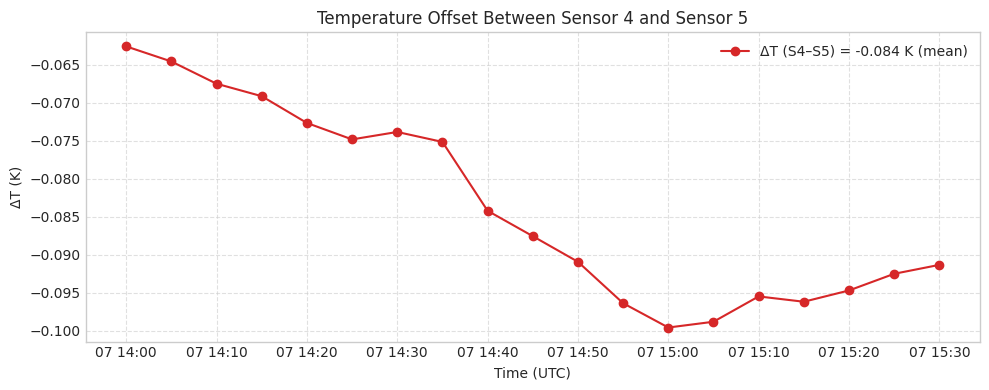

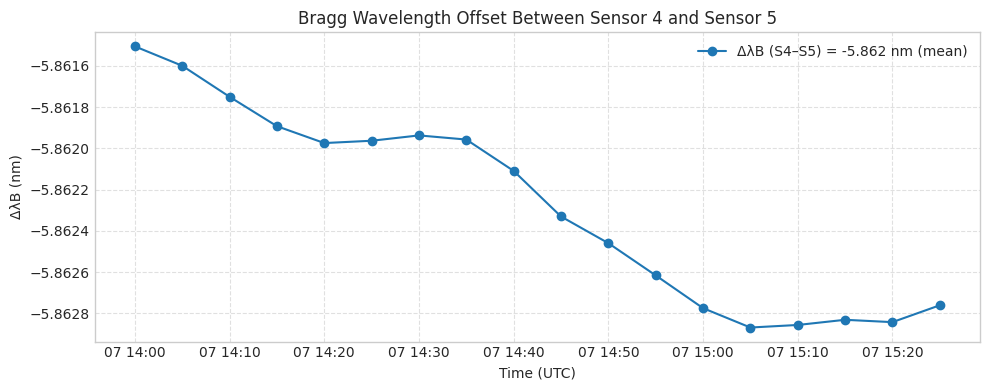

In [20]:
# --- Compare stability between Sensor 4 and Sensor 5 ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import uproot

# --- Load data again (if not in memory) ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root"
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Time conversion and correction ---
peak_timestamps = pd.to_datetime(peak_data["t"][:, 0], unit='s') + datetime.timedelta(hours=2)
temp_timestamps = pd.to_datetime(temp_data["t"], unit='s')

# --- Sensors 4 and 5 (indices 3 and 4 in 0-based) ---
s4, s5 = 3, 4

# --- Time window ---
start_time = datetime.datetime(2025, 11, 7, 14, 0, 0)
end_time   = datetime.datetime(2025, 11, 7, 15, 30, 0)

# --- λB (average over polarizations) ---
lambdaB_4 = (peak_data["wav"][:, 0, s4] + peak_data["wav"][:, 1, s4]) / 2
lambdaB_5 = (peak_data["wav"][:, 0, s5] + peak_data["wav"][:, 1, s5]) / 2

mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
df_peak4 = pd.DataFrame({"lambdaB_nm": lambdaB_4[mask_peak]*1e9}, index=peak_timestamps[mask_peak])
df_peak5 = pd.DataFrame({"lambdaB_nm": lambdaB_5[mask_peak]*1e9}, index=peak_timestamps[mask_peak])

# --- Temperature ---
temp_4 = temp_data["temp"][:, s4]
temp_5 = temp_data["temp"][:, s5]

mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)
df_temp4 = pd.DataFrame({"temp_K": temp_4[mask_temp]}, index=temp_timestamps[mask_temp])
df_temp5 = pd.DataFrame({"temp_K": temp_5[mask_temp]}, index=temp_timestamps[mask_temp])

# --- Resample to 5-minute intervals ---
peak4_res = df_peak4.resample("5min").mean()
peak5_res = df_peak5.resample("5min").mean()
temp4_res = df_temp4.resample("5min").mean()
temp5_res = df_temp5.resample("5min").mean()

# --- Compute offsets (Sensor 4 - Sensor 5) ---
temp_offset = temp4_res["temp_K"] - temp5_res["temp_K"]
lambdaB_offset = peak4_res["lambdaB_nm"] - peak5_res["lambdaB_nm"]

# --- Calculate mean offsets for legend ---
mean_temp_offset = temp_offset.mean()
mean_lambdaB_offset = lambdaB_offset.mean()

# --- Plot Temperature Offset ---
plt.figure(figsize=(10,4))
plt.plot(temp_offset.index, temp_offset, marker='o', color='tab:red', label=f"ΔT (S4–S5) = {mean_temp_offset:.3f} K (mean)")
plt.title("Temperature Offset Between Sensor 4 and Sensor 5")
plt.xlabel("Time (UTC)")
plt.ylabel("ΔT (K)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# --- Plot Bragg Wavelength Offset ---
plt.figure(figsize=(10,4))
plt.plot(lambdaB_offset.index, lambdaB_offset, marker='o', color='tab:blue', label=f"ΔλB (S4–S5) = {mean_lambdaB_offset:.3f} nm (mean)")
plt.title("Bragg Wavelength Offset Between Sensor 4 and Sensor 5")
plt.xlabel("Time (UTC)")
plt.ylabel("ΔλB (nm)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


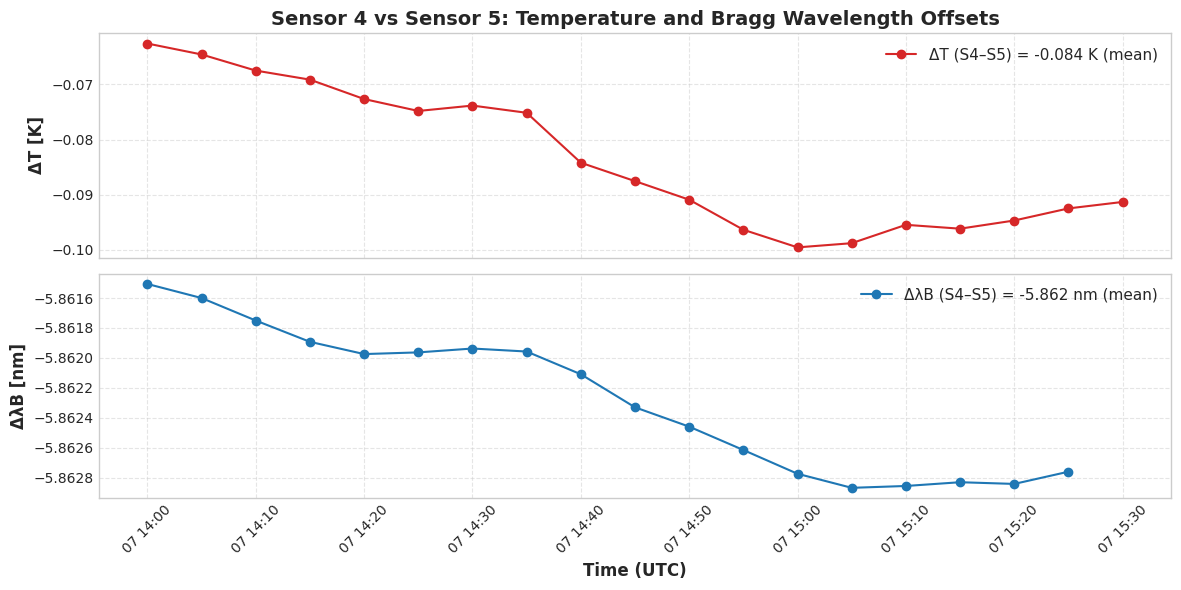

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import uproot

# --- Load data ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root"
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Time conversion and correction ---
peak_timestamps = pd.to_datetime(peak_data["t"][:, 0], unit='s') + datetime.timedelta(hours=2)
temp_timestamps = pd.to_datetime(temp_data["t"], unit='s')

# --- Sensors 4 and 5 (indices 3 and 4) ---
s4, s5 = 3, 4

# --- Time window ---
start_time = datetime.datetime(2025, 11, 7, 14, 0, 0)
end_time   = datetime.datetime(2025, 11, 7, 15, 30, 0)

# --- λB (average over polarizations) ---
lambdaB_4 = (peak_data["wav"][:, 0, s4] + peak_data["wav"][:, 1, s4]) / 2
lambdaB_5 = (peak_data["wav"][:, 0, s5] + peak_data["wav"][:, 1, s5]) / 2

mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
df_peak4 = pd.DataFrame({"lambdaB_nm": lambdaB_4[mask_peak]*1e9}, index=peak_timestamps[mask_peak])
df_peak5 = pd.DataFrame({"lambdaB_nm": lambdaB_5[mask_peak]*1e9}, index=peak_timestamps[mask_peak])

# --- Temperature ---
temp_4 = temp_data["temp"][:, s4]
temp_5 = temp_data["temp"][:, s5]
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)
df_temp4 = pd.DataFrame({"temp_K": temp_4[mask_temp]}, index=temp_timestamps[mask_temp])
df_temp5 = pd.DataFrame({"temp_K": temp_5[mask_temp]}, index=temp_timestamps[mask_temp])

# --- Resample to 5-minute intervals ---
peak4_res = df_peak4.resample("5min").mean()
peak5_res = df_peak5.resample("5min").mean()
temp4_res = df_temp4.resample("5min").mean()
temp5_res = df_temp5.resample("5min").mean()

# --- Compute offsets (Sensor 4 - Sensor 5) ---
temp_offset = temp4_res["temp_K"] - temp5_res["temp_K"]
lambdaB_offset = peak4_res["lambdaB_nm"] - peak5_res["lambdaB_nm"]

# --- Calculate mean offsets for legend ---
mean_temp_offset = temp_offset.mean()
mean_lambdaB_offset = lambdaB_offset.mean()

# --- Plot both offsets in one figure ---
fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Temperature offset
axs[0].plot(temp_offset.index, temp_offset, marker='o', color='tab:red',
            label=f"ΔT (S4–S5) = {mean_temp_offset:.3f} K (mean)")
axs[0].set_ylabel("ΔT [K]", fontsize=12, fontweight='bold')
axs[0].grid(True, linestyle="--", alpha=0.5)
axs[0].legend(fontsize=11)
axs[0].set_title("Sensor 4 vs Sensor 5: Temperature and Bragg Wavelength Offsets", fontsize=14, fontweight='bold')

# Bragg wavelength offset
axs[1].plot(lambdaB_offset.index, lambdaB_offset, marker='o', color='tab:blue',
            label=f"ΔλB (S4–S5) = {mean_lambdaB_offset:.3f} nm (mean)")
axs[1].set_ylabel("ΔλB [nm]", fontsize=12, fontweight='bold')
axs[1].set_xlabel("Time (UTC)", fontsize=12, fontweight='bold')
axs[1].grid(True, linestyle="--", alpha=0.5)
axs[1].legend(fontsize=11)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


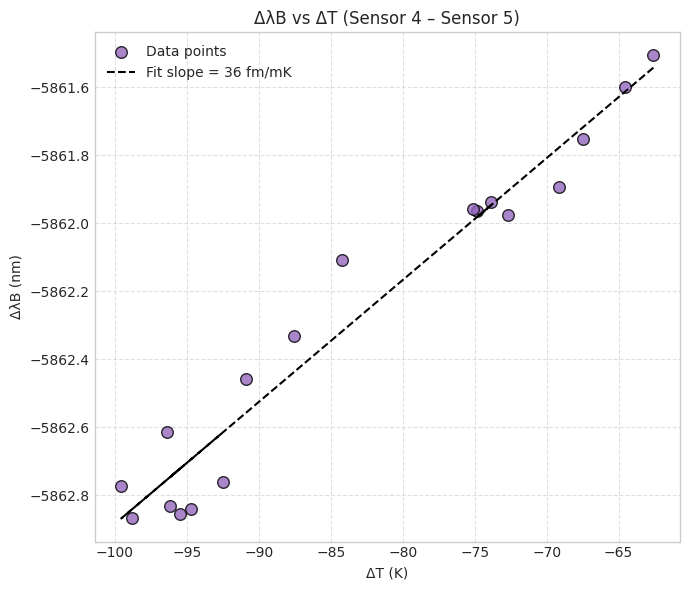

In [22]:
# --- ΔλB vs ΔT (Offset Correlation between Sensor 4 and 5) ---

# Ensure matching time index (they should already align via resampling)
df_offset = pd.concat([temp_offset, lambdaB_offset], axis=1).dropna()
df_offset.columns = ["delta_T", "delta_lambdaB"]

# --- Linear fit ---
x = 1e3*df_offset["delta_T"].values
y = 1e3*df_offset["delta_lambdaB"].values
if len(x) > 2:
    slope, intercept = np.polyfit(x, y, 1)
else:
    slope, intercept = np.nan, np.nan

# --- Plot ---
plt.figure(figsize=(7,6))
plt.scatter(x, y, color='tab:purple', s=70, alpha=0.8, edgecolor='k', label="Data points")
plt.plot(x, slope*x + intercept, 'k--', label=f"Fit slope = {1e3*slope:.0f} fm/mK")

plt.title("ΔλB vs ΔT (Sensor 4 – Sensor 5)")
plt.xlabel("ΔT (K)")
plt.ylabel("ΔλB (nm)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


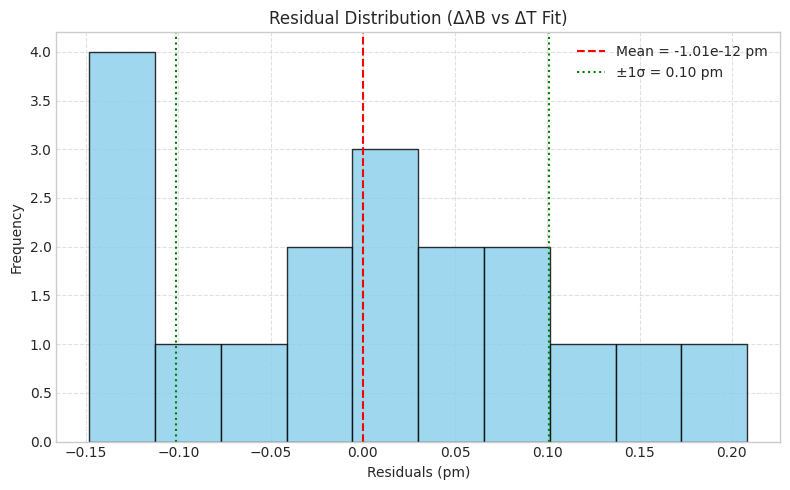

Residuals mean: -1.011e-12 pm
Residuals std:  0.101 pm


In [23]:
# --- Residual Analysis: Histogram of Fit Residuals ---

# Compute residuals (in pm)
y_fit = slope * x + intercept
residuals = y - y_fit  # in same units as y (pm)
res_mean = np.mean(residuals)
res_std = np.std(residuals)

# --- Plot histogram ---
plt.figure(figsize=(8,5))
plt.hist(residuals, bins=10, color='skyblue', edgecolor='k', alpha=0.8)
plt.axvline(res_mean, color='r', linestyle='--', label=f"Mean = {res_mean:.2e} pm")
plt.axvline(res_mean + res_std, color='g', linestyle=':', label=f"±1σ = {res_std:.2f} pm")
plt.axvline(res_mean - res_std, color='g', linestyle=':')

plt.title("Residual Distribution (ΔλB vs ΔT Fit)")
plt.xlabel("Residuals (pm)")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Print numerical results
print(f"Residuals mean: {res_mean:.3e} pm")
print(f"Residuals std:  {res_std:.3f} pm")


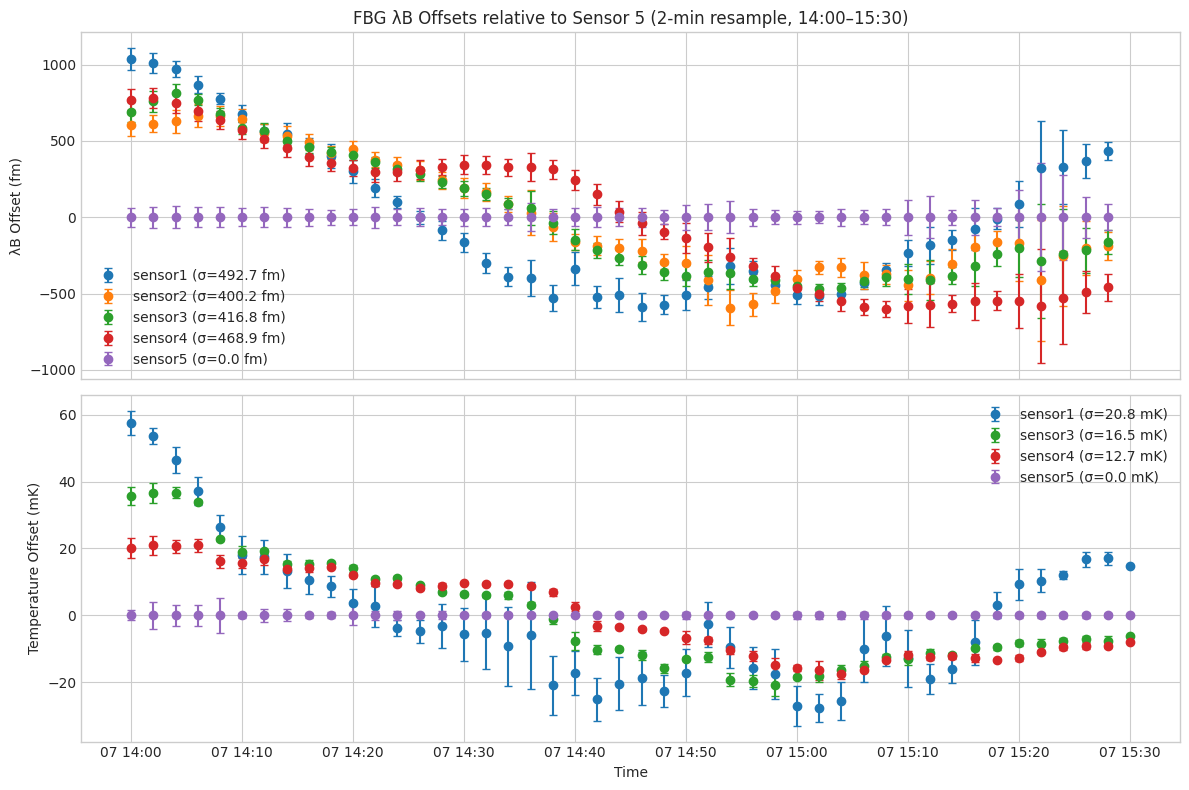

In [28]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251107.root"
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor indices ---
sensors_peak = [0, 1, 2, 3, 4]  # Sensor2 incluido
sensors_temp = [0, 2, 3, 4]     # Excluimos Sensor2

# --- Average polarizations ---
peak_times = peak_data["t"][:, 0]
sensor_lambdaB = np.mean(peak_data["wav"][:, :, :], axis=1)  # media sobre polarizaciones

temp_times = temp_data["t"]
sensor_temp = temp_data["temp"]

# --- Convert timestamps to datetime ---
peak_timestamps = pd.to_datetime(peak_times, unit='s')
temp_timestamps = pd.to_datetime(temp_times, unit='s')

# --- ✅ Apply +2 hour correction to peak timestamps ---
time_shift = datetime.timedelta(hours=2)
peak_timestamps = peak_timestamps + time_shift


# --- Filter time window ---
start_time = datetime.datetime(2025, 11, 7, 14, 0, 0)
end_time   = datetime.datetime(2025, 11, 7, 15, 30, 0)

mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)

peak_t_filtered = peak_timestamps[mask_peak]
lambdaB_filtered = sensor_lambdaB[mask_peak, :]

temp_t_filtered = temp_timestamps[mask_temp]
temp_filtered = sensor_temp[mask_temp, :]

# --- Build DataFrames ---
df_peak = pd.DataFrame(lambdaB_filtered * 1e15,  # convertir nm -> fm
                       columns=[f"sensor{i+1}" for i in range(lambdaB_filtered.shape[1])], 
                       index=peak_t_filtered)
df_temp = pd.DataFrame(temp_filtered[:, sensors_temp] * 1e3,  # K -> mK
                       columns=[f"sensor{i+1}" for i in sensors_temp], 
                       index=temp_t_filtered)

# --- Resample cada 2 minutos ---
peak_resampled = df_peak.resample("2min").agg(["mean","std"])
temp_resampled = df_temp.resample("2min").agg(["mean","std"])

# --- Compute offsets relative to Sensor5 (index 4) y centrar ---
lambda_mean = peak_resampled.xs('mean', axis=1, level=1)
lambda_offsets = lambda_mean.subtract(lambda_mean["sensor5"], axis=0)
lambda_offsets_centered = lambda_offsets - lambda_offsets.mean()

temp_mean = temp_resampled.xs('mean', axis=1, level=1)
temp_offsets = temp_mean.subtract(temp_mean["sensor5"], axis=0)
temp_offsets_centered = temp_offsets - temp_offsets.mean()

# --- Extract std for error bars ---
lambda_std = peak_resampled.xs('std', axis=1, level=1)
temp_std = temp_resampled.xs('std', axis=1, level=1)

# --- Compute total std along time for legend ---
lambda_std_total = lambda_offsets_centered.std()
temp_std_total = temp_offsets_centered.std()

# --- Plot ---
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]  # Sensor2 extra included for peaks

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8), sharex=True)

# Top subplot: λB offsets (scatter + std)
for i, s in enumerate(lambda_offsets_centered.columns):
    ax1.errorbar(peak_resampled.index, lambda_offsets_centered[s],
                 yerr=lambda_std[s], fmt='o', color=colors[i], capsize=3,
                 label=f"{s} (σ={lambda_std_total[s]:.1f} fm)")
ax1.set_ylabel("λB Offset (fm)")
ax1.set_title("FBG λB Offsets relative to Sensor 5 (2-min resample, 14:00–15:30)")
ax1.grid(True)
ax1.legend()

# Bottom subplot: Temperature offsets (scatter + std, exclude sensor2)
for i, s in enumerate(temp_offsets_centered.columns):
    ax2.errorbar(temp_resampled.index, temp_offsets_centered[s],
                 yerr=temp_std[s], fmt='o', color=colors[i if i<1 else i+1], capsize=3,
                 label=f"{s} (σ={temp_std_total[s]:.1f} mK)")
ax2.set_xlabel("Time")
ax2.set_ylabel("Temperature Offset (mK)")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()
